In [47]:
%pip install missingno

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder
from scipy import stats
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [49]:
# Load the data
train_path = '../data/raw/train.csv'
test_path = '../data/raw/test.csv'
sample_submission_path = '../data/raw/sample_submission.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_submission_path)

print(f"Train data shape: {train.shape}")
print(f"Test data shape: {test.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

Train data shape: (13998, 42)
Test data shape: (6000, 42)
Sample submission shape: (6000, 2)


In [50]:
# Display sample data
print("\nTrain data sample:")
train.head()


Train data sample:


,Latitude,Longitude,Station Code,Depth,Parameter Code,Analysis Method Code,Value Flags,Data Quality,Dataset_Source,temperature_avg,rainfall_mm,humidity_pct,pressure_hPa,drought_index,extreme_precip_days,urban_pct,forest_pct,agriculture_pct,water_pct,wetland_pct,grassland_pct,barren_pct,frag_index,soil_perm,ind_count,hg_impact,pb_impact,ind_risk_score,param_category,country_code,time_season,value_with_unit,sampling_method,is_referenced_method,water_body_type,analytical_program,pollution_risk,testing_laboratory,validated_results,sampling_weather,regulatory_framework,land_use_impact
0,50.903,NaN,CAN00062,NaN,OH,VMV_351,NaN,Fair,NaN,NaN,107.991,95.000,1005.215,1.795,NaN,5.951,31.264,24.570,9.798,7.870,NaN,4.582,0.689,0.580,1.000,0.175,0.261,11.968,Other,NaN,2016-07-06 12:00:00 - Summer,0.0 mg/l,NaN,False,Wetland,Provincial Monitoring,Medium,National Water Research Center,False,Snowy,NaN,Agricultural Dominant
1,NaN,NaN,NaN,0.300,NaN,NaN,NaN,Fair,carbon,NaN,76.765,85.981,1010.711,1.896,1.000,7.384,27.777,27.308,NaN,10.233,14.966,NaN,NaN,0.597,0.000,0.000,NaN,0.000,NaN,CHE,NaN,NaN,Composite Sample,True,NaN,NaN,Low,NaN,True,NaN,International Water Quality Standards,Agricultural Dominant
2,46.271,11.425,ITA00304,0.000,NaN,APAT3200_2003,<,Fair,mercury,-5.702,NaN,85.398,NaN,1.527,0.000,9.248,28.228,26.985,4.872,10.266,14.168,6.232,0.742,NaN,NaN,0.230,0.146,2.604,Heavy Metal,ITA,2011-07-05 00:00:00 - Summer,0.1 µg/l,Grab Sample,NaN,NaN,NaN,NaN,International Water Quality Lab,True,NaN,International Water Quality Standards,NaN
3,49.459,-120.504,CAN00328,0.300,Cs-Tot,VMV_3528,NaN,Fair,caesium,6.251,101.644,82.477,NaN,-1.133,2.000,5.334,26.070,26.362,NaN,5.621,16.146,7.908,0.672,0.573,2.000,0.291,NaN,2.256,NaN,NaN,2011-05-10 10:05:00 - Spring,NaN,Composite Sample,False,Reservoir,NaN,NaN,Canadian Analytical Services,True,Rainy,Fisheries Act,Agricultural Dominant
4,49.528,-115.549,CAN00204,0.300,Li-Tot,VMV_1919,NaN,Good,lithium,-9.855,NaN,80.189,NaN,1.638,0.000,6.655,NaN,24.677,10.277,7.911,NaN,6.495,NaN,0.574,1.000,0.737,1.817,3.178,Other,NaN,2005-08-02 10:00:00 - Summer,1.7 µg/l,Manual Sample,False,River,NaN,Medium,National Water Research Center,True,NaN,Canadian Environmental Protection Act,NaN


In [51]:
# Let's examine the distribution of the target variable - Data Quality
print("\nDistribution of target variable 'Data Quality':")
target_counts = train['Data Quality'].value_counts()
print(target_counts)



Distribution of target variable 'Data Quality':
Data Quality
Fair              10133
Unknown            3590
Good                251
Pending review       24
Name: count, dtype: int64


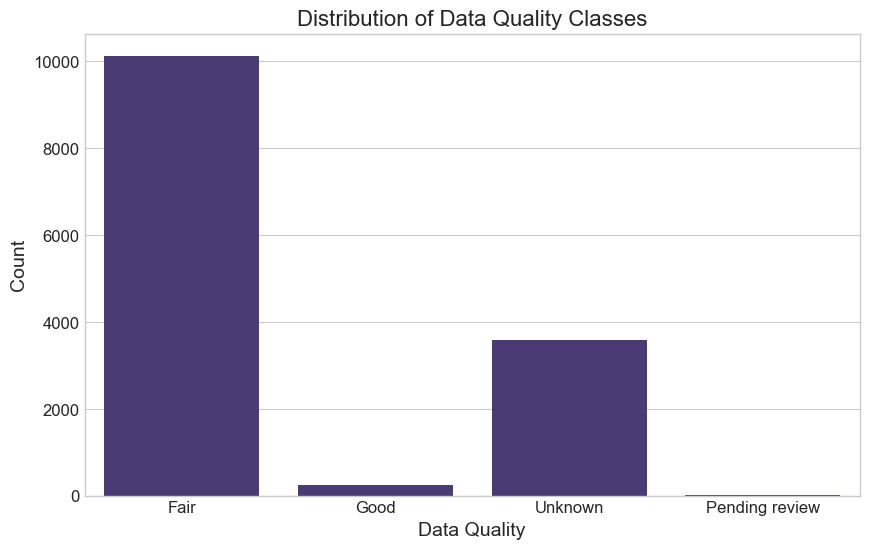

In [52]:
# Visualize target distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='Data Quality', data=train)
plt.title('Distribution of Data Quality Classes', fontsize=16)
plt.xlabel('Data Quality', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.savefig('../reports/figures/target_distribution.png', bbox_inches='tight')
plt.show()

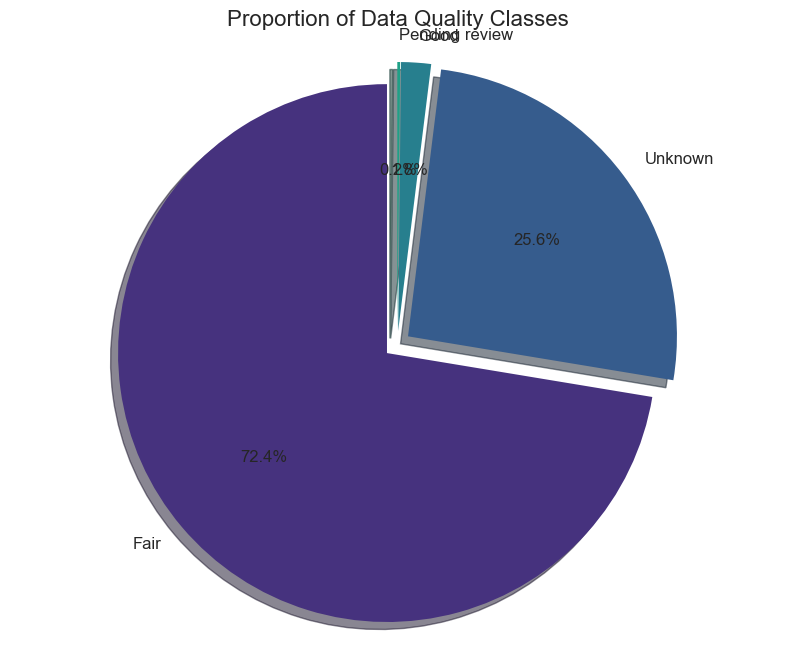

In [53]:
# Pie chart for better proportion visualization
plt.figure(figsize=(10, 8))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=90, 
        shadow=True, explode=[0.05] * len(target_counts))
plt.title('Proportion of Data Quality Classes', fontsize=16)
plt.axis('equal')
plt.savefig('../reports/figures/target_proportion.png', bbox_inches='tight')
plt.show()

In [54]:
# Check for missing values in train and test
print("\nMissing values analysis for train data:")
train_missing = train.isnull().sum().sort_values(ascending=False)
train_missing_percent = (train.isnull().sum() / train.shape[0] * 100).sort_values(ascending=False)
train_missing_df = pd.concat([train_missing, train_missing_percent], axis=1, 
                              keys=['Missing Count', 'Missing Percent'])
print(train_missing_df[train_missing_df['Missing Count'] > 0].head(20))

print("\nMissing values analysis for test data:")
test_missing = test.isnull().sum().sort_values(ascending=False)
test_missing_percent = (test.isnull().sum() / test.shape[0] * 100).sort_values(ascending=False)
test_missing_df = pd.concat([test_missing, test_missing_percent], axis=1, 
                             keys=['Missing Count', 'Missing Percent'])
print(test_missing_df[test_missing_df['Missing Count'] > 0].head(20))


Missing values analysis for train data:
                      Missing Count  Missing Percent
Value Flags                   11828           84.498
Analysis Method Code          11597           82.848
Longitude                      7073           50.529
pressure_hPa                   6814           48.678
analytical_program             6789           48.500
water_body_type                6634           47.392
Dataset_Source                 6212           44.378
drought_index                  5979           42.713
pollution_risk                 5798           41.420
pb_impact                      5667           40.484
Station Code                   5360           38.291
rainfall_mm                    5174           36.962
sampling_weather               5015           35.827
barren_pct                     4558           32.562
temperature_avg                4517           32.269
value_with_unit                4499           32.140
Depth                          4445           31.755
count

<Figure size 1600x1000 with 0 Axes>

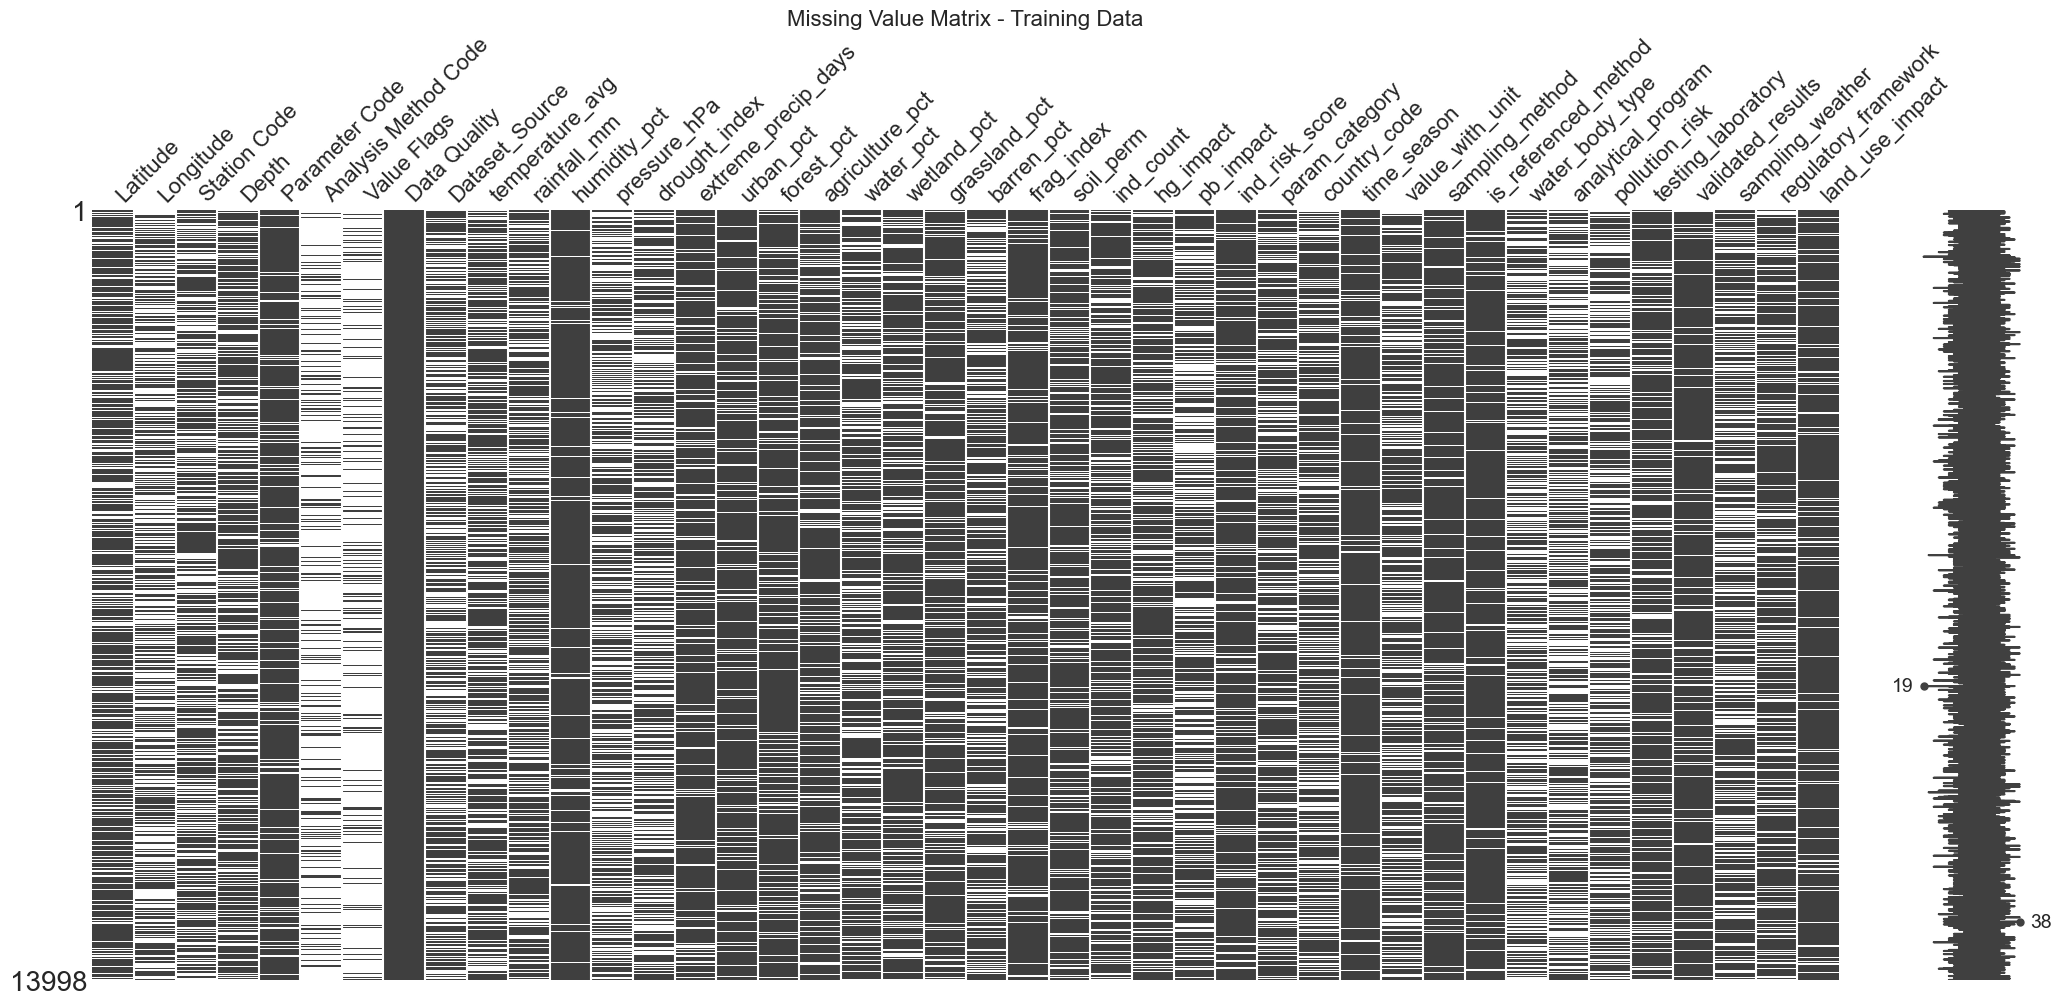

<Figure size 1600x1000 with 0 Axes>

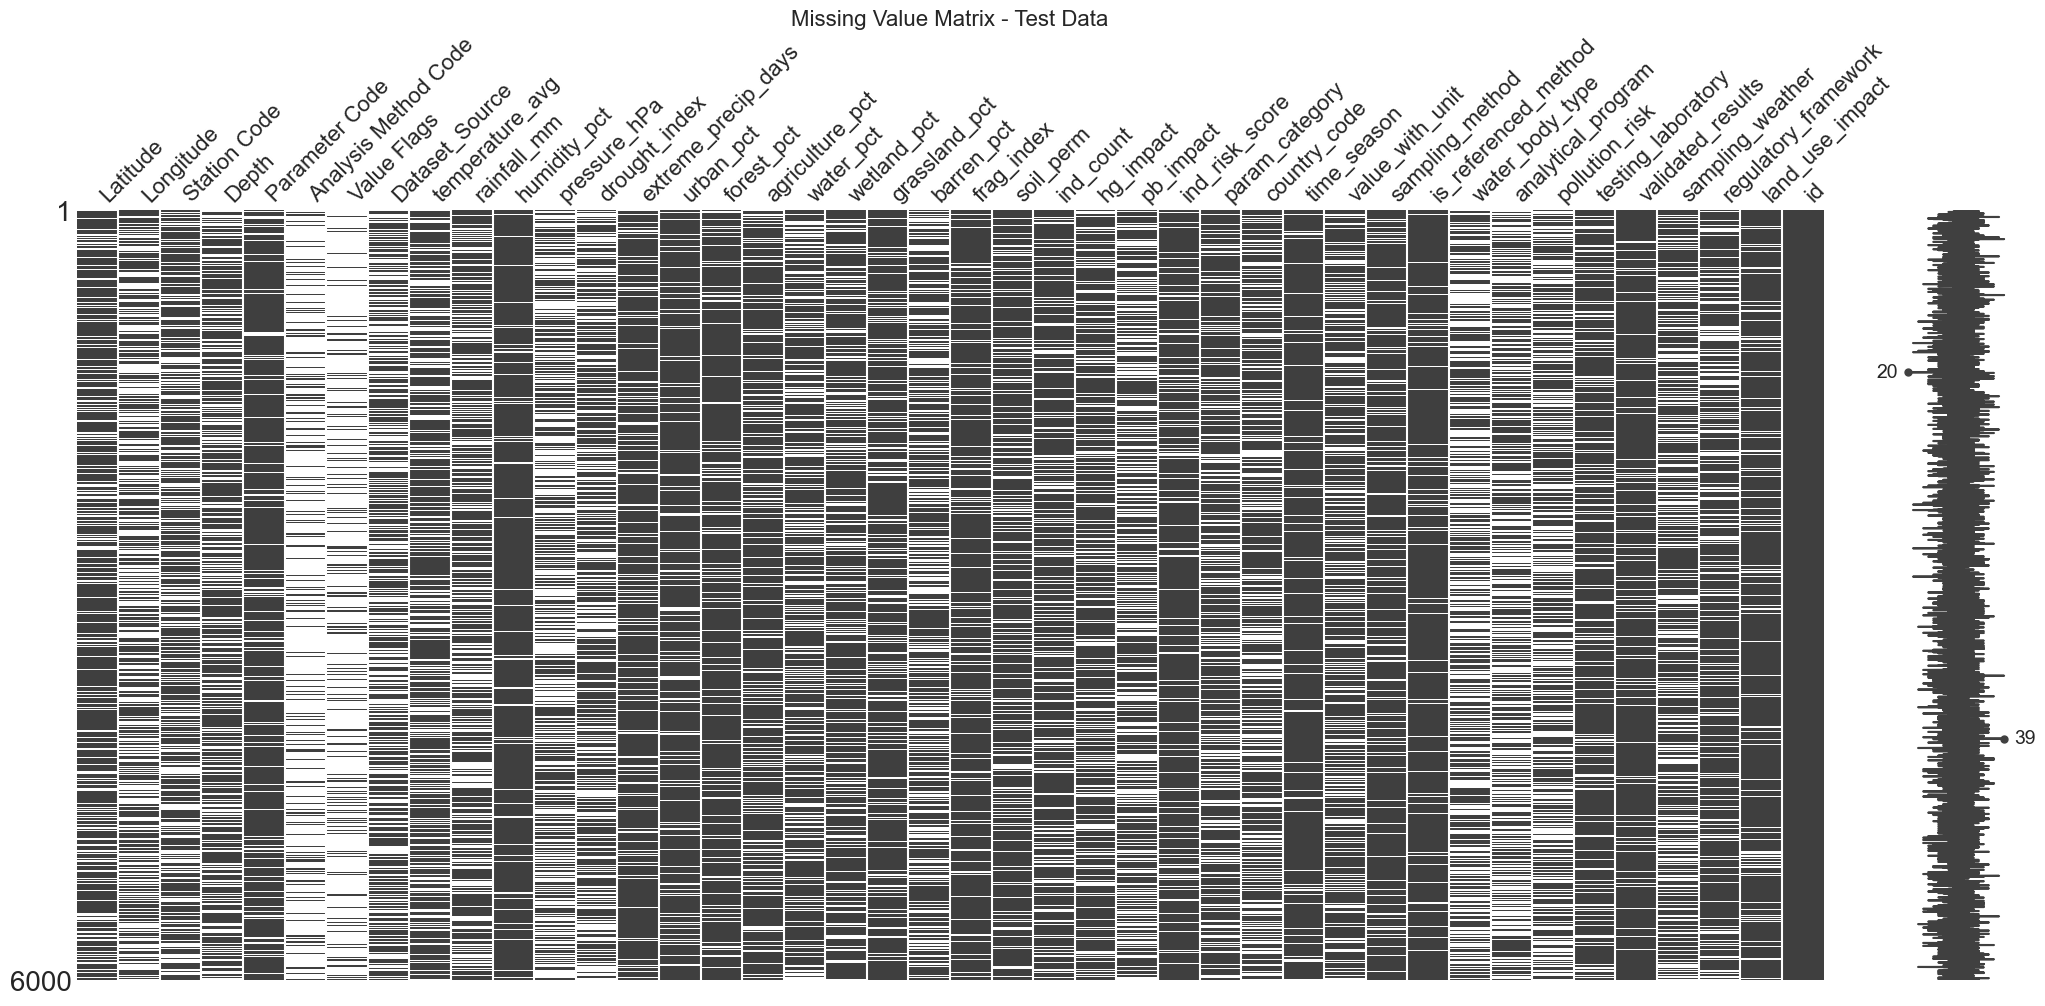

In [55]:
# Visualize missing values
plt.figure(figsize=(16, 10))
msno.matrix(train)
plt.title('Missing Value Matrix - Training Data', fontsize=16)
plt.savefig('../reports/figures/train_missing_matrix.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(16, 10))
msno.matrix(test)
plt.title('Missing Value Matrix - Test Data', fontsize=16)
plt.savefig('../reports/figures/test_missing_matrix.png', bbox_inches='tight')
plt.show()

In [56]:
# Check data types of all columns
print("\nData types in train dataset:")
print(train.dtypes)


Data types in train dataset:
Latitude                float64
Longitude               float64
Station Code             object
Depth                   float64
Parameter Code           object
Analysis Method Code     object
Value Flags              object
Data Quality             object
Dataset_Source           object
temperature_avg         float64
rainfall_mm             float64
humidity_pct            float64
pressure_hPa            float64
drought_index           float64
extreme_precip_days     float64
urban_pct               float64
forest_pct              float64
agriculture_pct         float64
water_pct               float64
wetland_pct             float64
grassland_pct           float64
barren_pct              float64
frag_index              float64
soil_perm               float64
ind_count               float64
hg_impact               float64
pb_impact               float64
ind_risk_score          float64
param_category           object
country_code             object
time_seaso

In [57]:
# Analyzing numerical features
numerical_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nNumber of numerical features: {len(numerical_features)}")
print(f"Numerical features: {numerical_features}")


Number of numerical features: 22
Numerical features: ['Latitude', 'Longitude', 'Depth', 'temperature_avg', 'rainfall_mm', 'humidity_pct', 'pressure_hPa', 'drought_index', 'extreme_precip_days', 'urban_pct', 'forest_pct', 'agriculture_pct', 'water_pct', 'wetland_pct', 'grassland_pct', 'barren_pct', 'frag_index', 'soil_perm', 'ind_count', 'hg_impact', 'pb_impact', 'ind_risk_score']


In [58]:
# Statistical summary of numerical features
print("\nStatistical summary of numerical features:")
print(train[numerical_features].describe())


Statistical summary of numerical features:
       Latitude  Longitude    Depth  temperature_avg  rainfall_mm  \
count 10388.000   6925.000 9553.000         9481.000     8824.000   
mean     35.436    -27.693    0.456            6.825       80.874   
std      16.220     75.701    5.159           10.630       28.562   
min     -51.688   -162.883    0.000          -22.621       15.497   
25%      21.395   -100.810    0.300           -1.069       57.892   
50%      36.339     -6.649    0.300            7.008       78.730   
75%      49.148     21.983    0.300           14.660      101.414   
max      81.843     96.171  300.000           32.337      201.616   

       humidity_pct  pressure_hPa  drought_index  extreme_precip_days  \
count     13149.000      7184.000       8019.000            11975.000   
mean         80.595      1008.436          0.006                1.273   
std           8.840         3.688          1.159                1.356   
min          49.147       995.417         

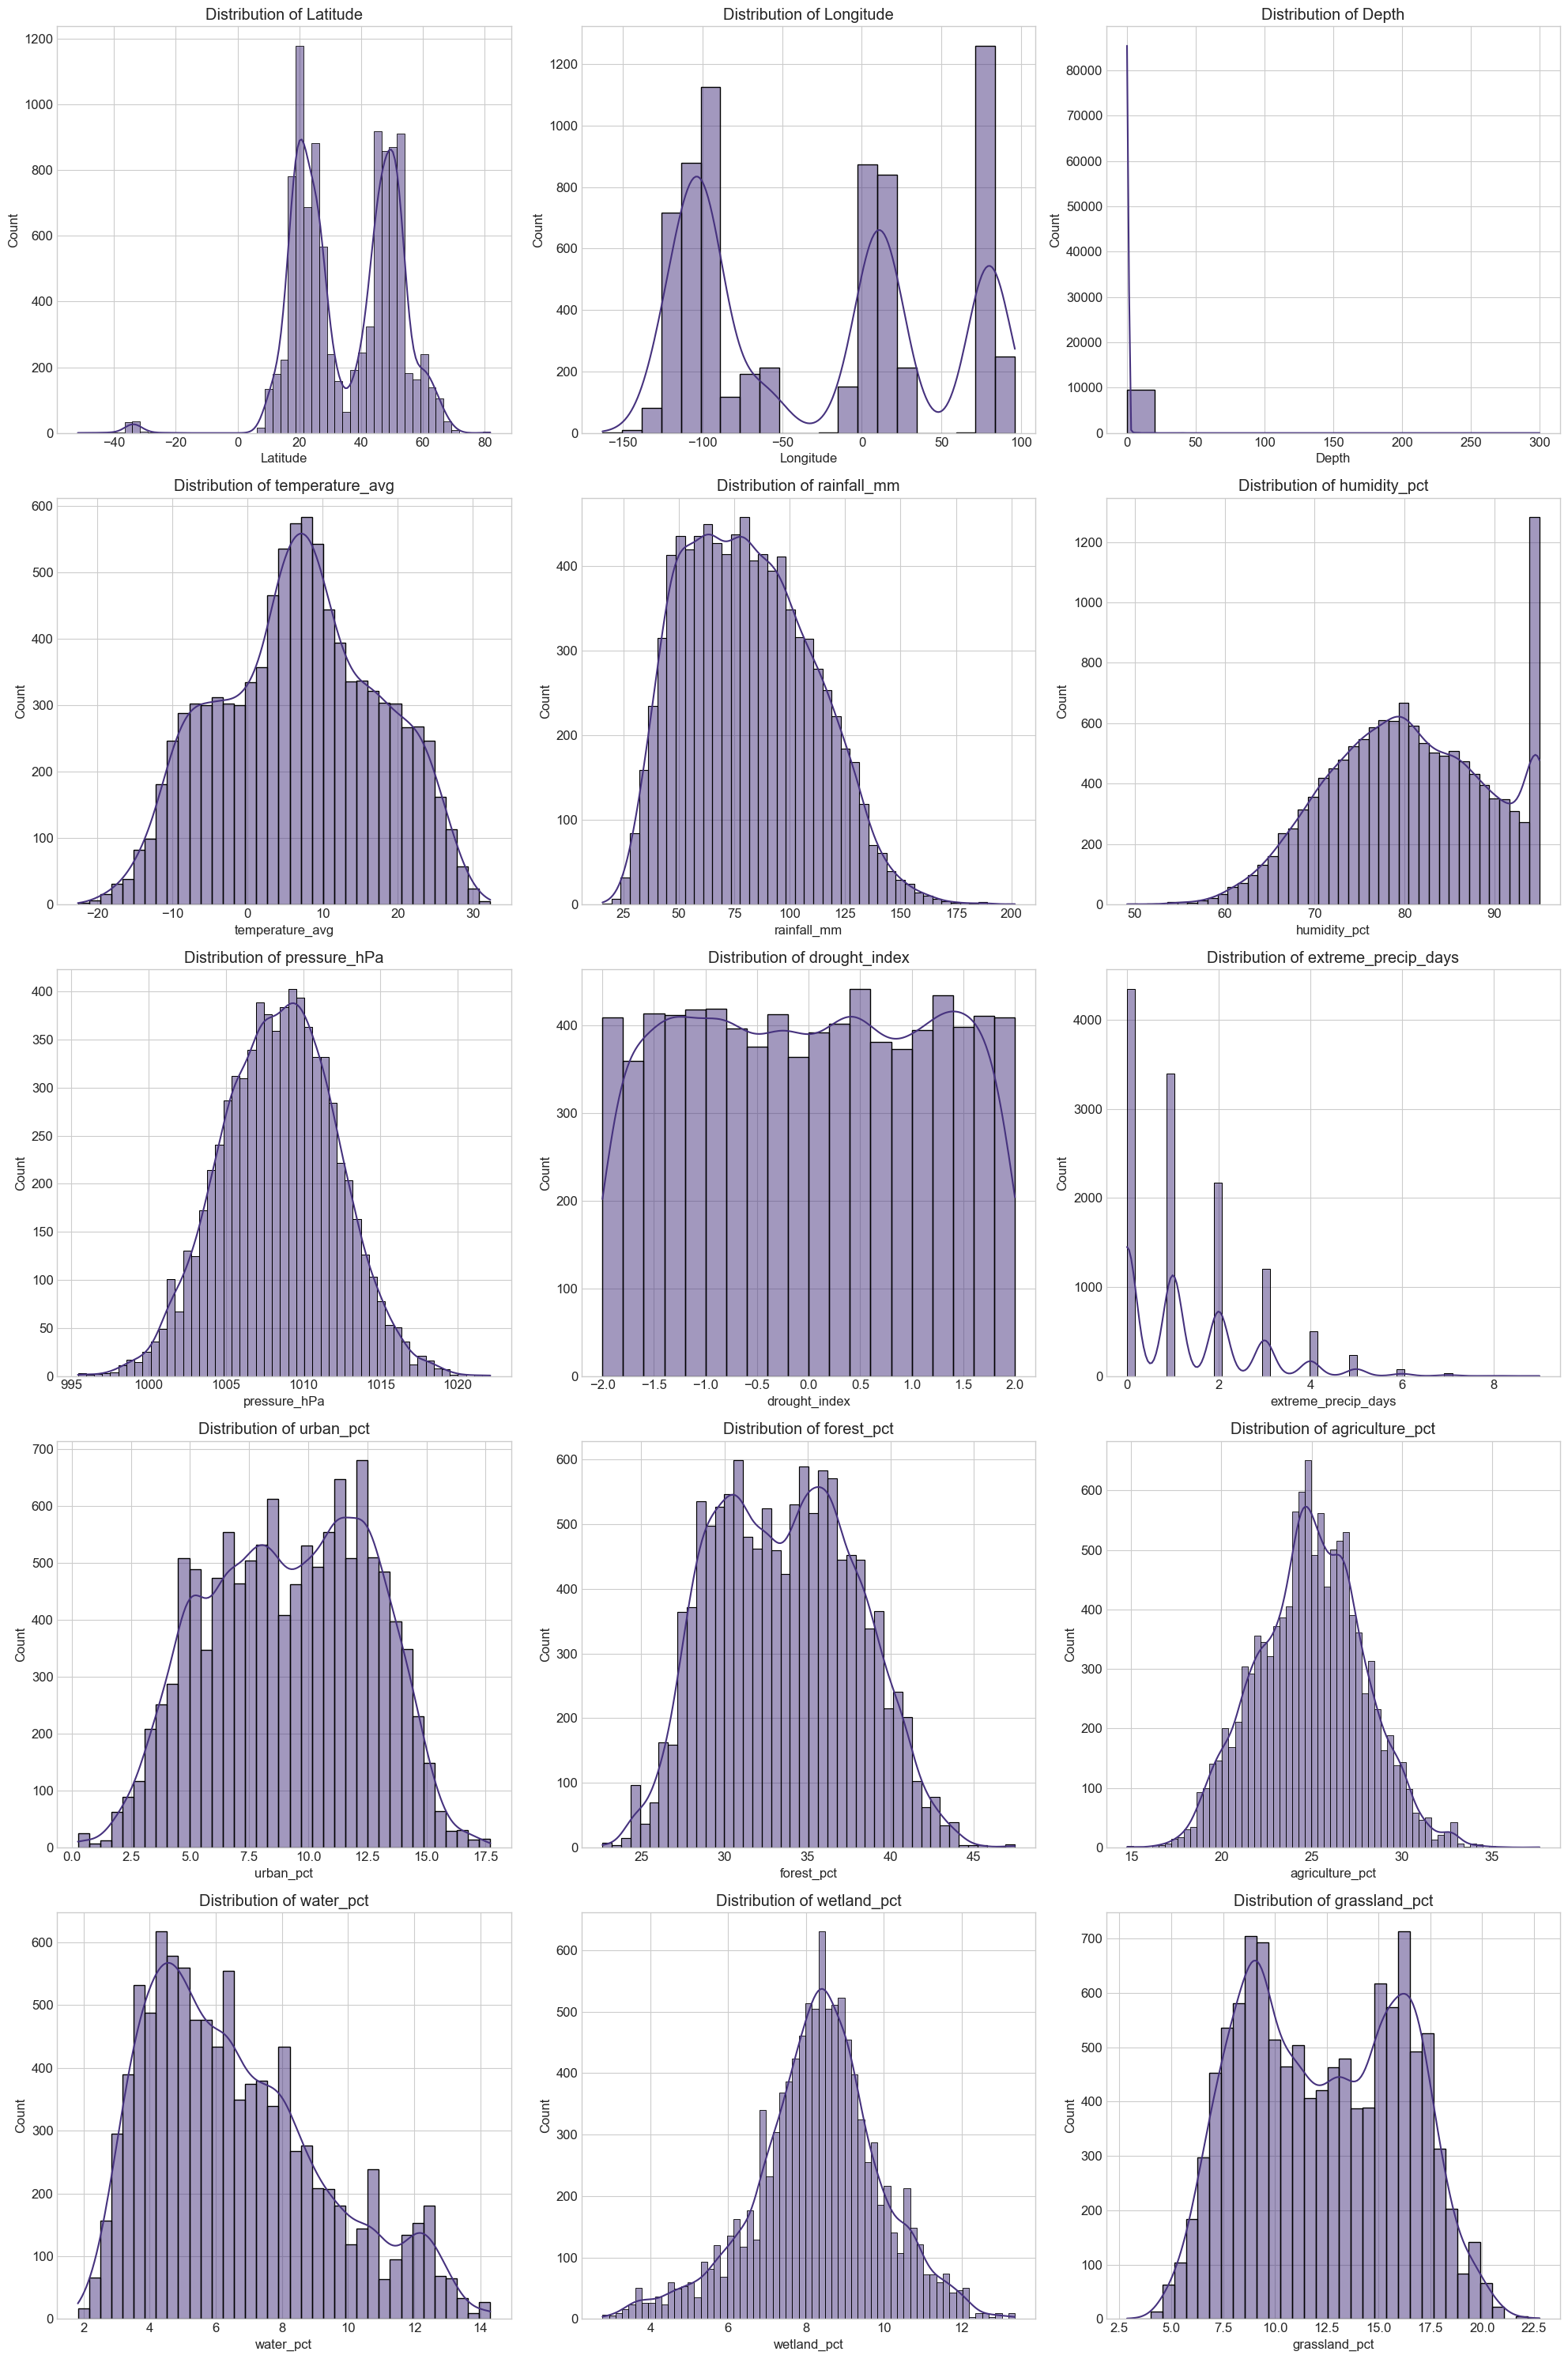

In [59]:
# Distribution of numerical features
plt.figure(figsize=(20, 30))
for i, feature in enumerate(numerical_features[:min(15, len(numerical_features))]):
    plt.subplot(5, 3, i+1)
    sns.histplot(train[feature].dropna(), kde=True)
    plt.title(f'Distribution of {feature}')
    plt.tight_layout()
plt.savefig('../reports/figures/numerical_distributions.png', bbox_inches='tight')
plt.show()


ANALISIS KOLOM TEMPERATURE_AVG

Statistik dasar temperature_avg:
count   9481.000
mean       6.825
std       10.630
min      -22.621
25%       -1.069
50%        7.008
75%       14.660
max       32.337
Name: temperature_avg, dtype: float64

Missing values: 4517 (32.27%)

Nilai minimum: -22.62°C
Nilai maksimum: 32.34°C
Range suhu: 54.96°C


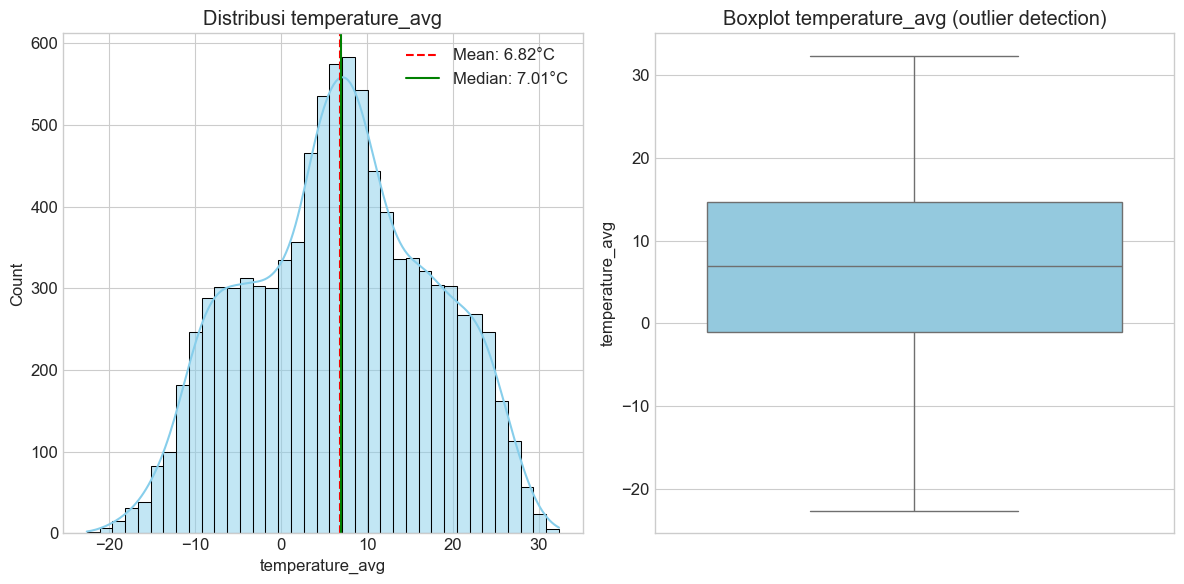


Jumlah outlier: 0 (0.00% dari data)
Batas bawah outlier: -24.66°C
Batas atas outlier: 38.25°C
Rentang normal (non-outlier): [-24.66°C, 38.25°C]


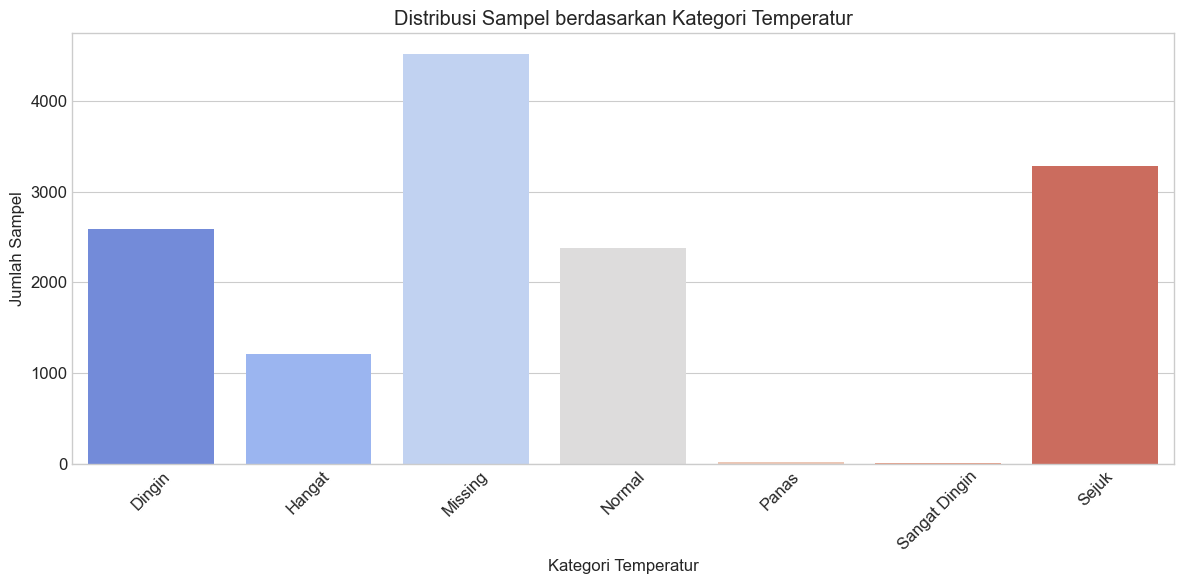

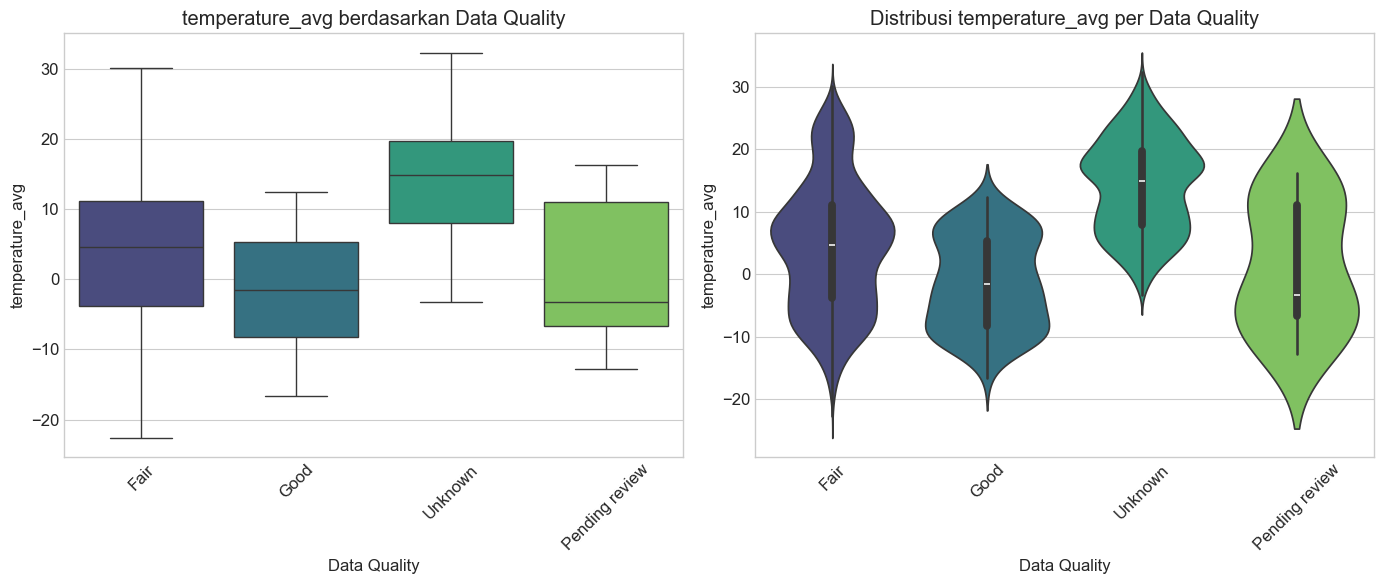


Statistik temperature_avg berdasarkan Data Quality:
                 mean  median    std  count
Data Quality                               
Fair            4.456   4.651 10.394   6866
Good           -1.404  -1.592  7.318    177
Pending review  1.266  -3.293 10.201     15
Unknown        14.174  14.907  7.517   2423


<Figure size 1400x800 with 0 Axes>

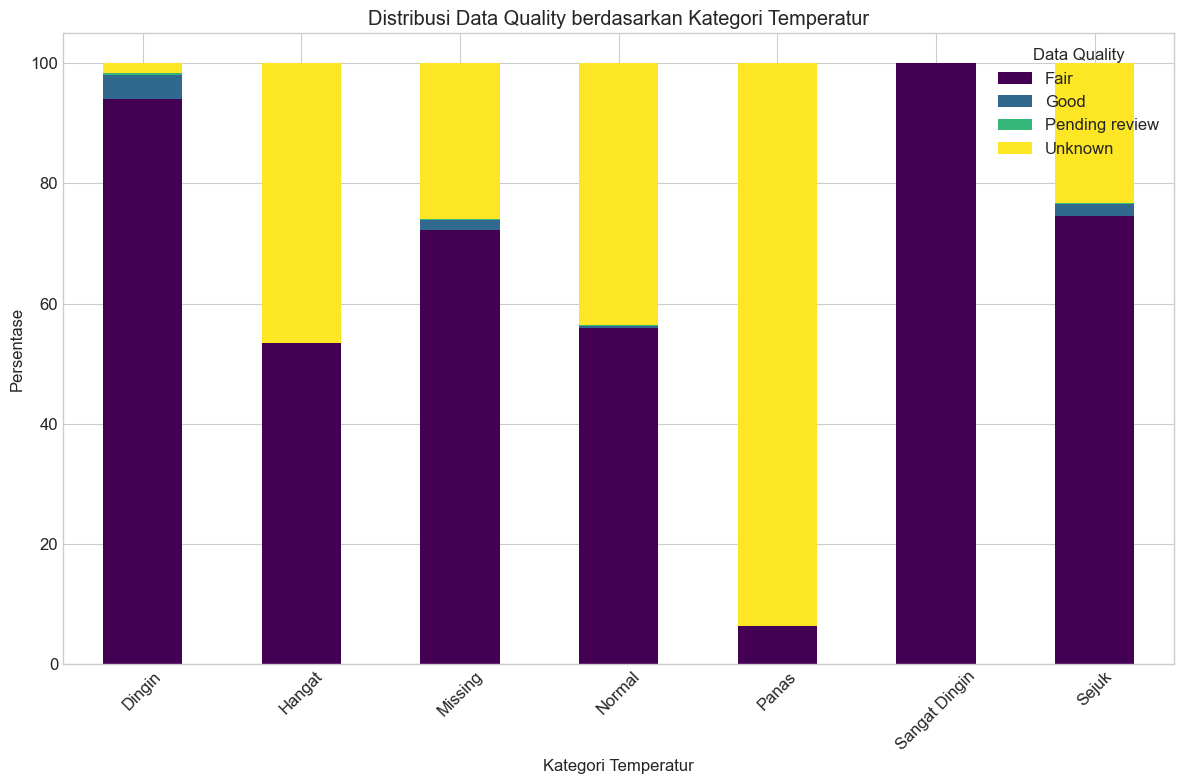


Korelasi temperature_avg dengan fitur numerik lain:
  - Latitude: 0.6627
  - forest_pct: 0.5056
  - grassland_pct: 0.4870
  - pressure_hPa: 0.4642
  - rainfall_mm: 0.3984
  - urban_pct: 0.3950
  - frag_index: 0.3847
  - barren_pct: 0.3268
  - agriculture_pct: 0.2470
  - extreme_precip_days: 0.2303


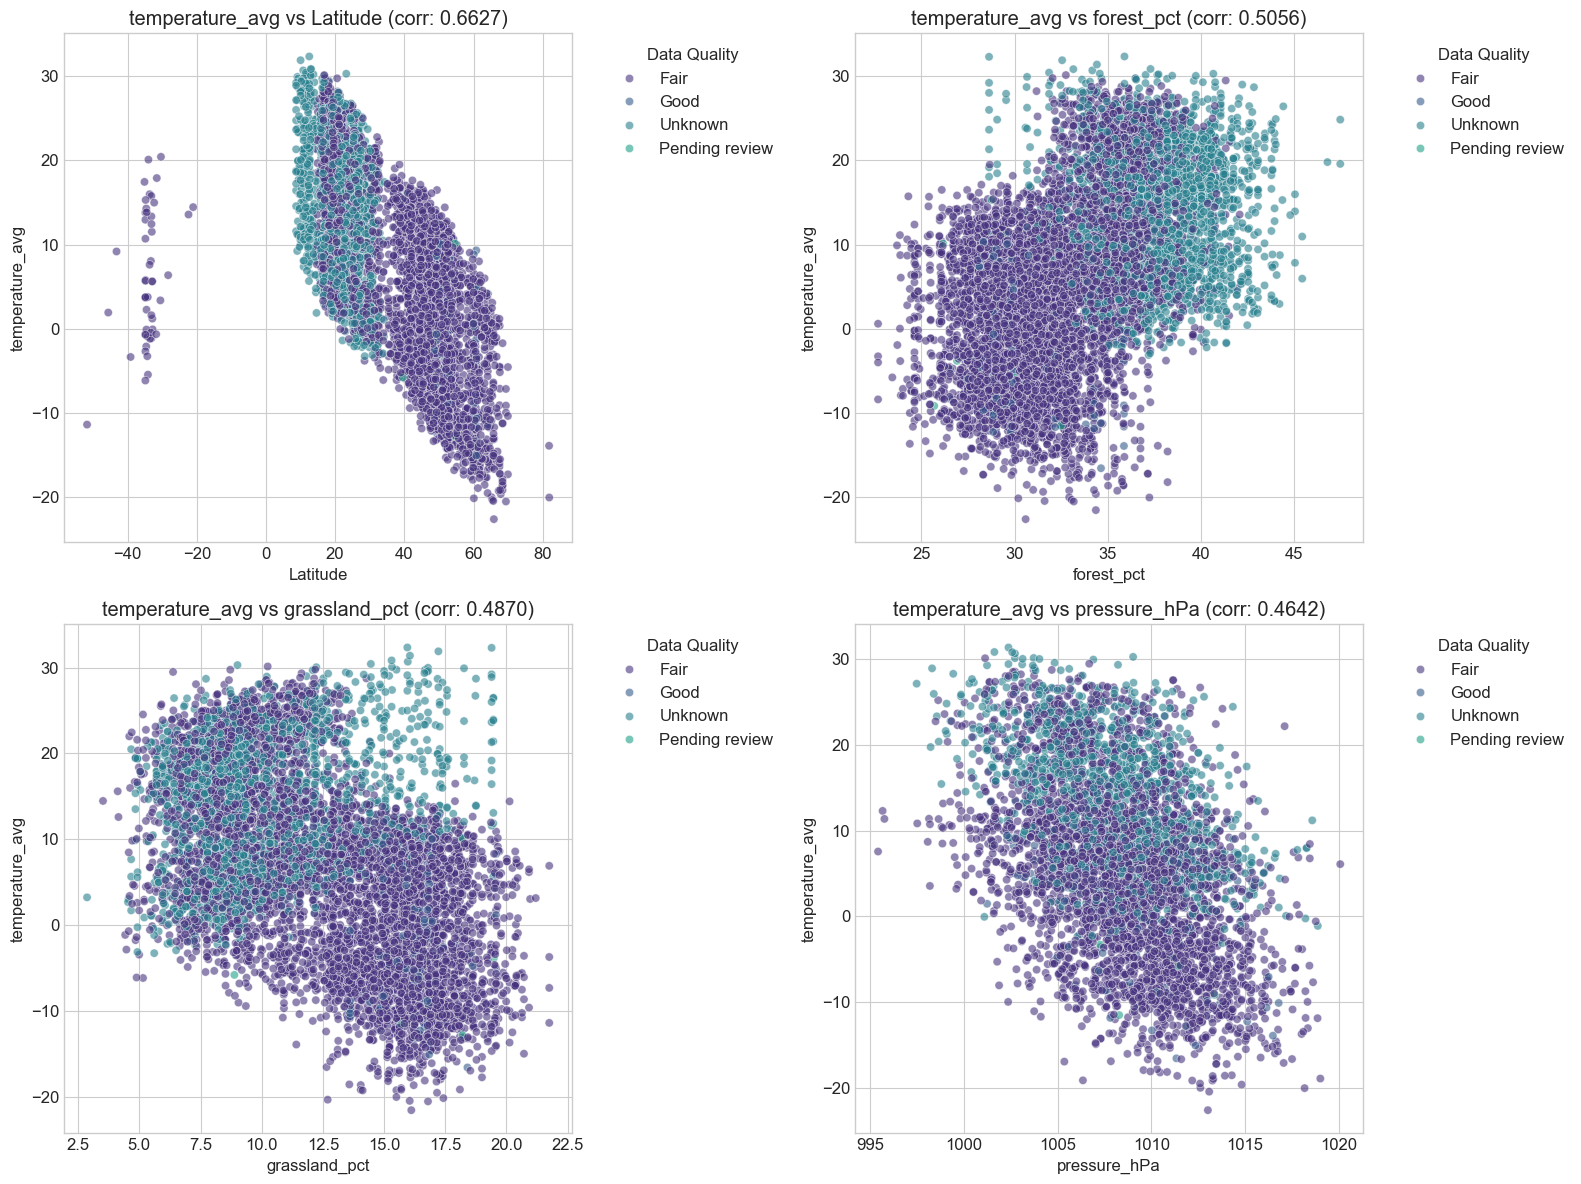

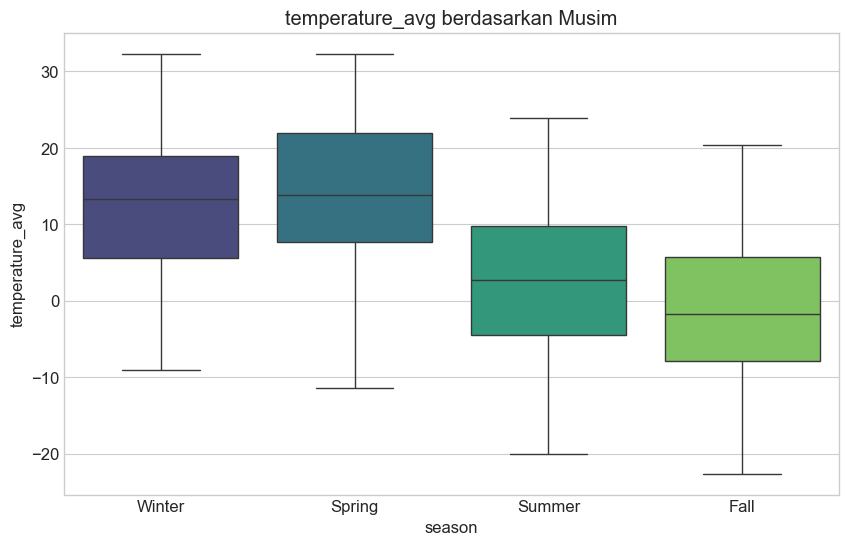


Statistik temperature_avg berdasarkan Musim:
         mean  median   std  count
season                            
Winter 12.360  13.306 8.322   2054
Spring 14.491  13.839 8.231   2194
Summer  2.569   2.674 8.794   2372
Fall   -1.264  -1.768 8.117   2205


<Figure size 1200x600 with 0 Axes>

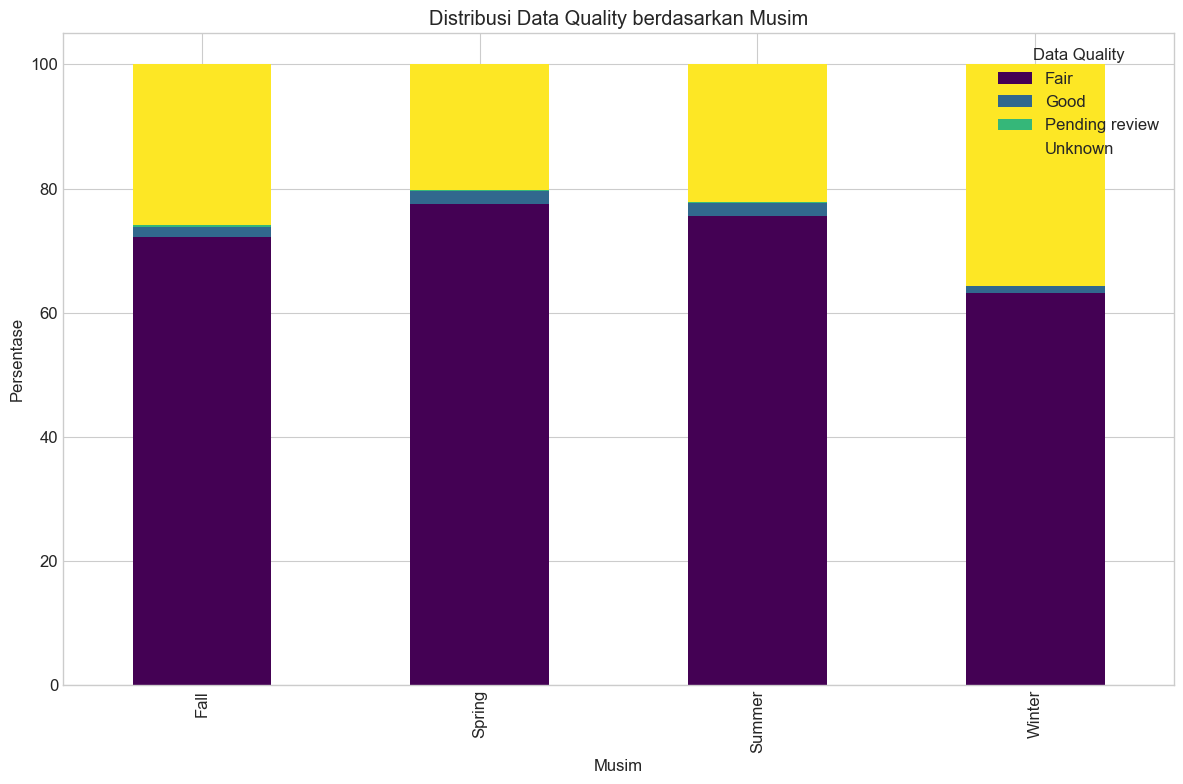

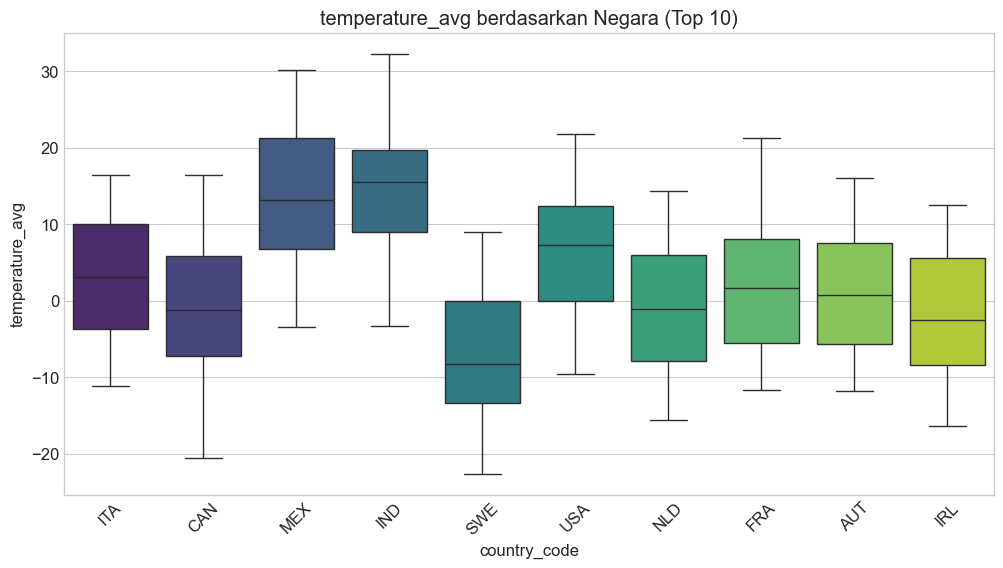


Statistik temperature_avg berdasarkan Negara (Top 10):
               mean  median   std  count
country_code                            
MEX          13.771  13.197 8.085   1636
IND          14.653  15.516 7.180   1379
CAN          -0.942  -1.157 7.698   1088
USA           6.503   7.365 7.474    388
ITA           3.159   3.076 7.413    352
NLD          -1.022  -1.035 7.447    344
SWE          -6.838  -8.304 7.617    181
IRL          -1.673  -2.541 7.663    148
FRA           1.522   1.634 7.776    141
AUT           1.063   0.792 7.405    112


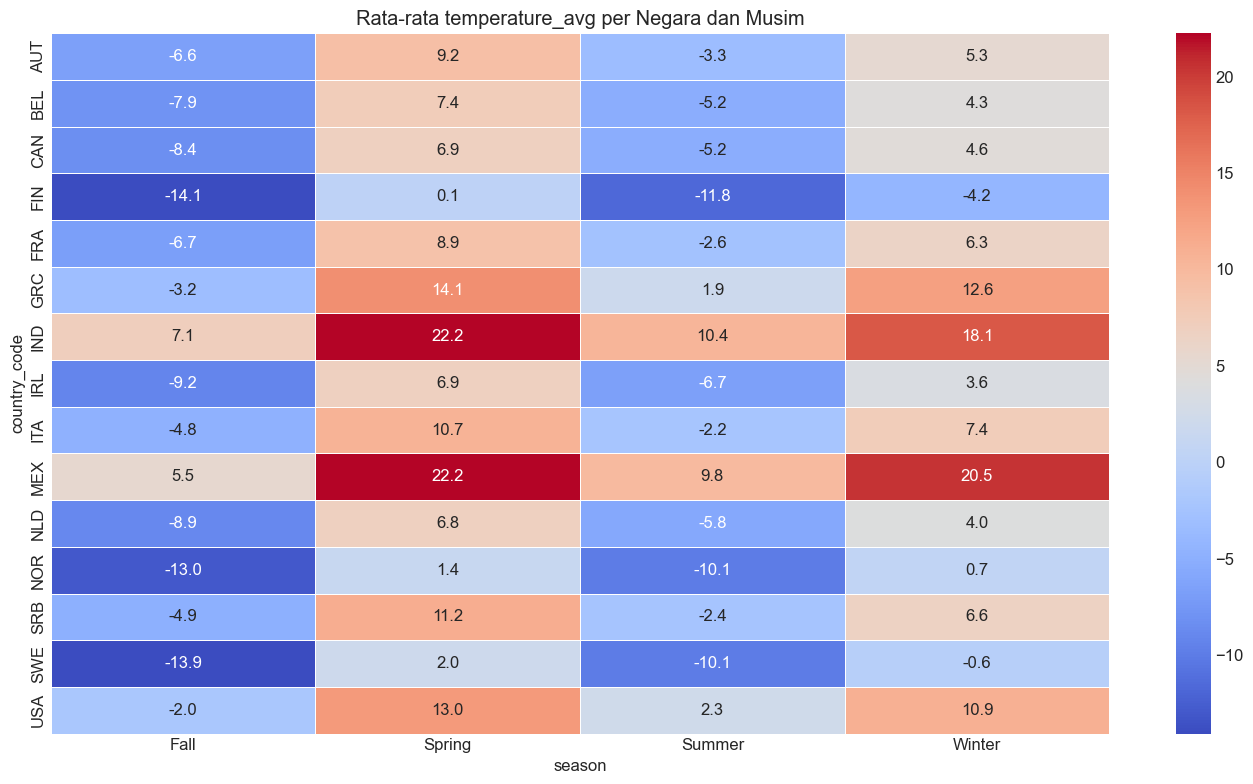

In [61]:
# Analisis khusus untuk kolom temperature_avg
print("\n" + "="*50)
print("ANALISIS KOLOM TEMPERATURE_AVG")
print("="*50)

# Pastikan kolom ada di dataset
if 'temperature_avg' in train.columns:
    # Statistik dasar
    temp_stats = train['temperature_avg'].describe()
    print("\nStatistik dasar temperature_avg:")
    print(temp_stats)
    
    # Hitung missing values
    temp_missing = train['temperature_avg'].isna().sum()
    temp_missing_percent = (temp_missing / len(train)) * 100
    print(f"\nMissing values: {temp_missing} ({temp_missing_percent:.2f}%)")
    
    # Cek nilai minimum dan maksimum
    print(f"\nNilai minimum: {train['temperature_avg'].min():.2f}°C")
    print(f"Nilai maksimum: {train['temperature_avg'].max():.2f}°C")
    print(f"Range suhu: {train['temperature_avg'].max() - train['temperature_avg'].min():.2f}°C")
    
    # Visualisasi distribusi
    plt.figure(figsize=(12, 6))
    
    # Histogram dengan KDE
    plt.subplot(1, 2, 1)
    sns.histplot(train['temperature_avg'].dropna(), kde=True, color='skyblue')
    plt.title('Distribusi temperature_avg')
    plt.axvline(train['temperature_avg'].mean(), color='r', linestyle='--', label=f'Mean: {train["temperature_avg"].mean():.2f}°C')
    plt.axvline(train['temperature_avg'].median(), color='g', linestyle='-', label=f'Median: {train["temperature_avg"].median():.2f}°C')
    plt.legend()
    
    # Boxplot untuk outlier
    plt.subplot(1, 2, 2)
    sns.boxplot(y=train['temperature_avg'].dropna(), color='skyblue')
    plt.title('Boxplot temperature_avg (outlier detection)')
    
    plt.tight_layout()
    # Buat direktori jika belum ada
    os.makedirs('../reports/figures', exist_ok=True)
    plt.savefig('../reports/figures/temperature_avg_analysis.png', bbox_inches='tight')
    plt.show()
    
    # Identifikasi outlier menggunakan metode IQR
    Q1 = train['temperature_avg'].quantile(0.25)
    Q3 = train['temperature_avg'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train[(train['temperature_avg'] < lower_bound) | (train['temperature_avg'] > upper_bound)]
    print(f"\nJumlah outlier: {len(outliers)} ({len(outliers)/len(train)*100:.2f}% dari data)")
    print(f"Batas bawah outlier: {lower_bound:.2f}°C")
    print(f"Batas atas outlier: {upper_bound:.2f}°C")
    print(f"Rentang normal (non-outlier): [{lower_bound:.2f}°C, {upper_bound:.2f}°C]")
    
    # Buat dataframe untuk batasan temperatur menurut standar klimatologi
    temp_ranges = pd.DataFrame({
        'Range': ['Sangat Dingin', 'Dingin', 'Sejuk', 'Normal', 'Hangat', 'Panas', 'Sangat Panas'],
        'Min Temp': [-50, -20, 0, 10, 20, 30, 40],
        'Max Temp': [-20, 0, 10, 20, 30, 40, 60]
    })
    
    # Hitung distribusi temperature berdasarkan range
    def get_temp_category(temp, ranges):
        for i, row in ranges.iterrows():
            if row['Min Temp'] <= temp < row['Max Temp']:
                return row['Range']
        return 'Ekstrem'
    
    train['temp_category'] = train['temperature_avg'].apply(lambda x: get_temp_category(x, temp_ranges) if pd.notna(x) else 'Missing')
    
    # Visualisasi distribusi berdasarkan kategori temperatur
    plt.figure(figsize=(12, 6))
    temp_cat_counts = train['temp_category'].value_counts().sort_index()
    sns.barplot(x=temp_cat_counts.index, y=temp_cat_counts.values, palette='coolwarm')
    plt.title('Distribusi Sampel berdasarkan Kategori Temperatur')
    plt.xlabel('Kategori Temperatur')
    plt.ylabel('Jumlah Sampel')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../reports/figures/temperature_categories.png', bbox_inches='tight')
    plt.show()
    
    # Distribusi temperature_avg berdasarkan target (jika ada di data)
    if 'Data Quality' in train.columns:
        plt.figure(figsize=(14, 6))
        
        # Boxplot per kategori
        plt.subplot(1, 2, 1)
        sns.boxplot(x='Data Quality', y='temperature_avg', data=train, palette='viridis')
        plt.title('temperature_avg berdasarkan Data Quality')
        plt.xticks(rotation=45)
        
        # Violin plot untuk distribusi lebih detail
        plt.subplot(1, 2, 2)
        sns.violinplot(x='Data Quality', y='temperature_avg', data=train, palette='viridis')
        plt.title('Distribusi temperature_avg per Data Quality')
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.savefig('../reports/figures/temperature_avg_by_target.png', bbox_inches='tight')
        plt.show()
        
        # Nilai rata-rata dan median per kategori
        temp_by_quality = train.groupby('Data Quality')['temperature_avg'].agg(['mean', 'median', 'std', 'count'])
        print("\nStatistik temperature_avg berdasarkan Data Quality:")
        print(temp_by_quality)
        
        # Analisis distribusi kategori temperatur per Data Quality
        plt.figure(figsize=(14, 8))
        cross_tab = pd.crosstab(train['temp_category'], train['Data Quality'], normalize='index') * 100
        cross_tab.plot(kind='bar', stacked=True, colormap='viridis')
        plt.title('Distribusi Data Quality berdasarkan Kategori Temperatur')
        plt.xlabel('Kategori Temperatur')
        plt.ylabel('Persentase')
        plt.xticks(rotation=45)
        plt.legend(title='Data Quality')
        plt.tight_layout()
        plt.savefig('../reports/figures/temp_category_vs_target.png', bbox_inches='tight')
        plt.show()
        
    # Korelasi dengan fitur numerik lain
    if len(numerical_features) > 1:
        # Pilih 10 fitur numerik dengan korelasi tertinggi dengan temperature_avg
        corr_with_temp = train[numerical_features].corr()['temperature_avg'].abs().sort_values(ascending=False)
        top_corr = corr_with_temp[1:11]  # Skip self-correlation
        
        print("\nKorelasi temperature_avg dengan fitur numerik lain:")
        for col, corr in top_corr.items():
            print(f"  - {col}: {corr:.4f}")
        
        # Visualisasi korelasi dengan scatter plots
        plt.figure(figsize=(16, 12))
        for i, col in enumerate(top_corr.index[:4]):  # Plot top 4
            plt.subplot(2, 2, i+1)
            sns.scatterplot(x=col, y='temperature_avg', data=train, alpha=0.6, hue='Data Quality' if 'Data Quality' in train.columns else None)
            plt.title(f'temperature_avg vs {col} (corr: {corr_with_temp[col]:.4f})')
            if 'Data Quality' in train.columns:
                plt.legend(title='Data Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.savefig('../reports/figures/temperature_avg_correlations.png', bbox_inches='tight')
        plt.show()
        
    # Analisis berdasarkan musim (jika ada)
    if 'time_season' in train.columns:
        # Ekstrak musim dari time_season
        train['season'] = train['time_season'].str.split(' - ').str[1]
        
        plt.figure(figsize=(10, 6))
        season_order = ['Winter', 'Spring', 'Summer', 'Fall']
        season_data = train[train['season'].isin(season_order)]
        
        if len(season_data) > 0:
            sns.boxplot(x='season', y='temperature_avg', data=season_data, 
                        order=season_order, palette='viridis')
            plt.title('temperature_avg berdasarkan Musim')
            plt.savefig('../reports/figures/temperature_avg_by_season.png', bbox_inches='tight')
            plt.show()
            
            # Statistik per musim
            temp_by_season = train.groupby('season')['temperature_avg'].agg(['mean', 'median', 'std', 'count'])
            # Reindex untuk mengurutkan musim
            if all(season in temp_by_season.index for season in season_order):
                temp_by_season = temp_by_season.reindex(season_order)
            print("\nStatistik temperature_avg berdasarkan Musim:")
            print(temp_by_season)
            
            # Distribusi target per musim
            if 'Data Quality' in train.columns:
                plt.figure(figsize=(12, 6))
                cross_tab = pd.crosstab(season_data['season'], season_data['Data Quality'], normalize='index') * 100
                cross_tab.plot(kind='bar', stacked=True, colormap='viridis')
                plt.title('Distribusi Data Quality berdasarkan Musim')
                plt.xlabel('Musim')
                plt.ylabel('Persentase')
                plt.legend(title='Data Quality')
                plt.tight_layout()
                plt.savefig('../reports/figures/data_quality_by_season.png', bbox_inches='tight')
                plt.show()
    
    # Analisis berdasarkan negara (jika ada)
    if 'country_code' in train.columns:
        # Top 10 negara dengan sampel terbanyak
        top_countries = train['country_code'].value_counts().head(10).index
        
        plt.figure(figsize=(12, 6))
        sns.boxplot(x='country_code', y='temperature_avg', data=train[train['country_code'].isin(top_countries)], 
                   palette='viridis')
        plt.title('temperature_avg berdasarkan Negara (Top 10)')
        plt.xticks(rotation=45)
        plt.savefig('../reports/figures/temperature_avg_by_country.png', bbox_inches='tight')
        plt.show()
        
        # Statistik per negara
        temp_by_country = train.groupby('country_code')['temperature_avg'].agg(['mean', 'median', 'std', 'count'])
        temp_by_country = temp_by_country.sort_values(by='count', ascending=False).head(10)
        print("\nStatistik temperature_avg berdasarkan Negara (Top 10):")
        print(temp_by_country)
        
        # Peta panas untuk nilai temperatur di berbagai negara dan musim
        if 'season' in train.columns:
            plt.figure(figsize=(14, 8))
            pivot_table = pd.pivot_table(train, values='temperature_avg', 
                                        index='country_code', columns='season', 
                                        aggfunc='mean')
            # Pilih top 15 negara dengan sampel terbanyak
            top_countries = train['country_code'].value_counts().head(15).index
            pivot_filtered = pivot_table.loc[pivot_table.index.isin(top_countries)]
            
            sns.heatmap(pivot_filtered, annot=True, cmap='coolwarm', fmt='.1f', linewidths=.5)
            plt.title('Rata-rata temperature_avg per Negara dan Musim')
            plt.tight_layout()
            plt.savefig('../reports/figures/temperature_country_season_heatmap.png', bbox_inches='tight')
            plt.show()
else:
    print("Kolom temperature_avg tidak ditemukan dalam dataset.")

In [ ]:
# Check for skewness in numerical features
print("\nSkewness in numerical features:")
skewness = train[numerical_features].skew().sort_values(ascending=False)
print(skewness)


Skewness in numerical features:
pb_impact             47.773
Depth                 46.316
hg_impact             32.953
ind_risk_score         4.569
ind_count              3.498
extreme_precip_days    1.215
water_pct              0.677
rainfall_mm            0.351
Longitude              0.180
soil_perm              0.114
forest_pct             0.105
grassland_pct          0.070
agriculture_pct        0.027
drought_index         -0.001
pressure_hPa          -0.032
temperature_avg       -0.049
humidity_pct          -0.097
urban_pct             -0.108
barren_pct            -0.147
frag_index            -0.215
wetland_pct           -0.296
Latitude              -0.471
dtype: float64


In [ ]:
# Analyzing categorical features
categorical_features = train.select_dtypes(include=['object']).columns.tolist()
print(f"\nNumber of categorical features: {len(categorical_features)}")
print(f"Categorical features: {categorical_features}")


Number of categorical features: 20
Categorical features: ['Station Code', 'Parameter Code', 'Analysis Method Code', 'Value Flags', 'Data Quality', 'Dataset_Source', 'param_category', 'country_code', 'time_season', 'value_with_unit', 'sampling_method', 'is_referenced_method', 'water_body_type', 'analytical_program', 'pollution_risk', 'testing_laboratory', 'validated_results', 'sampling_weather', 'regulatory_framework', 'land_use_impact']


In [ ]:
# Count unique values in categorical features
cat_unique_counts = {col: train[col].nunique() for col in categorical_features}
cat_unique_counts = pd.Series(cat_unique_counts).sort_values(ascending=False)
print("\nUnique values count in categorical features:")
print(cat_unique_counts)


Unique values count in categorical features:
time_season             7618
value_with_unit         4104
Station Code            3970
Analysis Method Code     136
Parameter Code           121
Dataset_Source            39
country_code              34
testing_laboratory        11
analytical_program        10
regulatory_framework       9
water_body_type            8
sampling_weather           6
sampling_method            5
param_category             5
pollution_risk             4
Data Quality               4
land_use_impact            4
is_referenced_method       2
validated_results          2
Value Flags                2
dtype: int64


In [ ]:
# Analyze top categorical features with high cardinality
high_cardinality_features = cat_unique_counts[cat_unique_counts > 10].index.tolist()
print(f"\nHigh cardinality features (>10 unique values): {high_cardinality_features}")


High cardinality features (>10 unique values): ['time_season', 'value_with_unit', 'Station Code', 'Analysis Method Code', 'Parameter Code', 'Dataset_Source', 'country_code', 'testing_laboratory']



Distribution of regulatory_framework:
regulatory_framework
International Water Quality Standards    8568
Fisheries Act                             612
Provincial Water Regulations              571
Canadian Environmental Protection Act     568
EU Water Framework Directive               57
Mediterranean Action Plan                  57
Greek Environmental Law                    55
Polish Water Law                           14
Baltic Sea Protection Convention            9
Name: count, dtype: int64


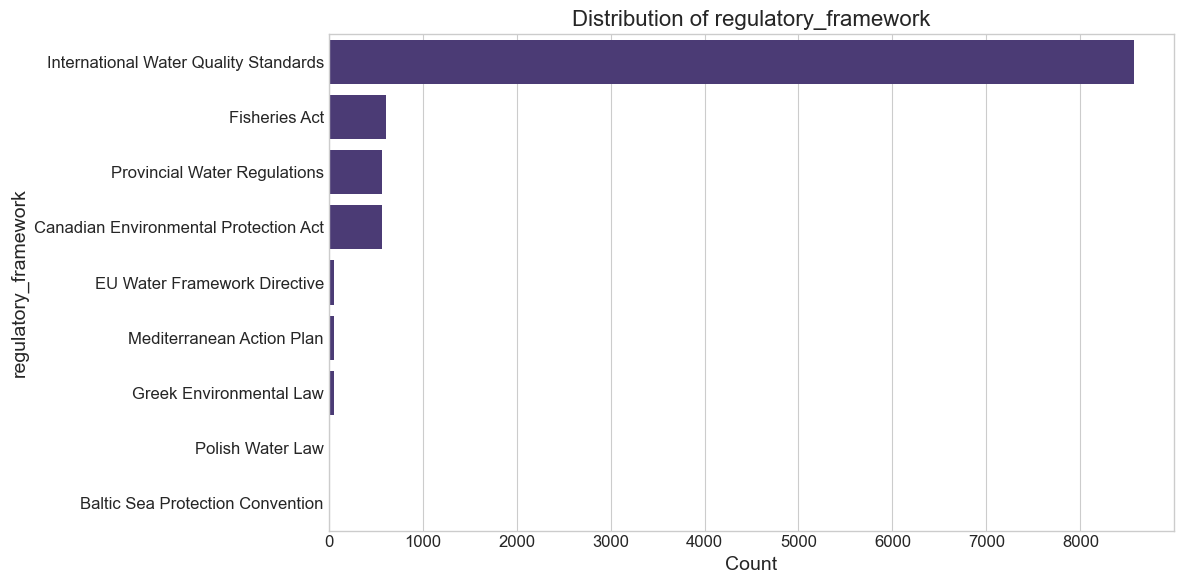


Distribution of water_body_type:
water_body_type
Lake           970
Reservoir      949
Estuary        945
Groundwater    931
Wetland        928
River          902
Marine         884
Stream         855
Name: count, dtype: int64


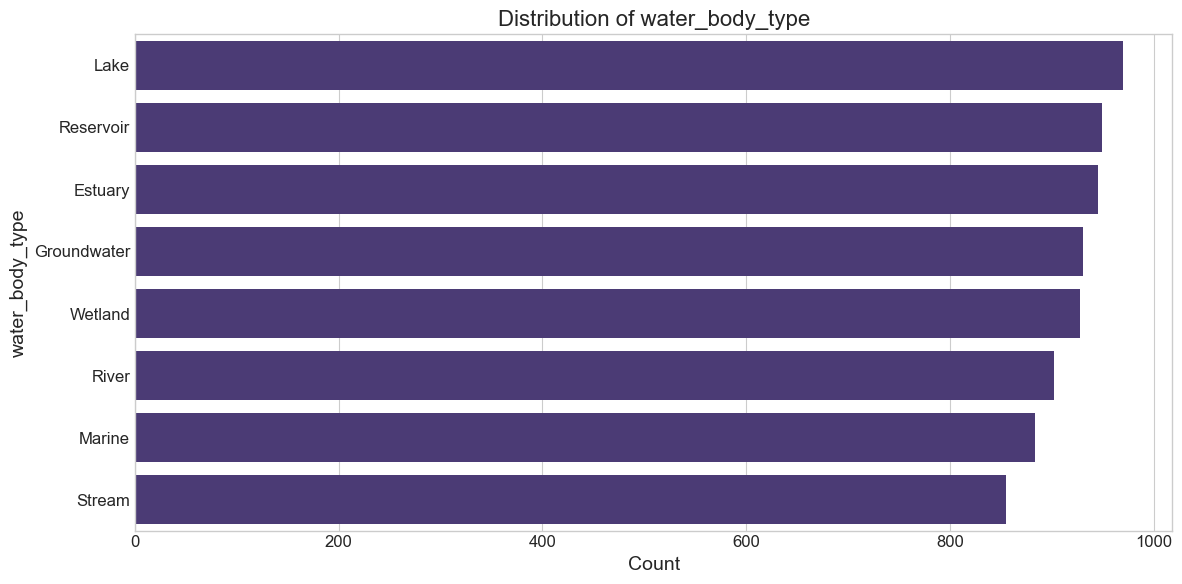


Distribution of sampling_weather:
sampling_weather
Cloudy    1928
Rainy     1849
Clear     1618
Snowy     1394
Foggy     1196
Stormy     998
Name: count, dtype: int64


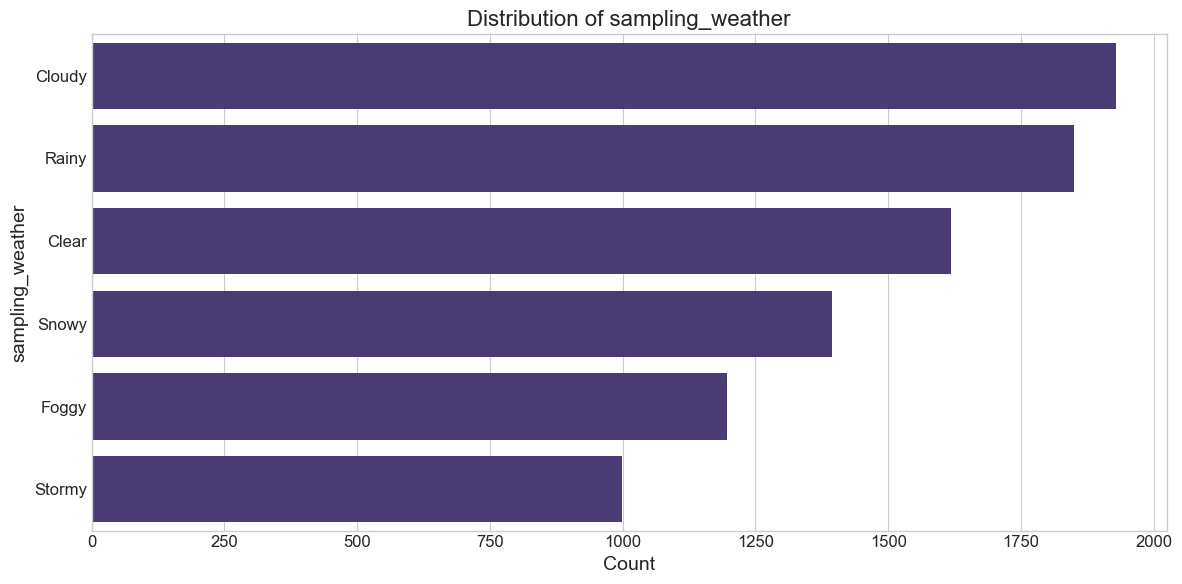


Distribution of sampling_method:
sampling_method
Field Measurement    2510
Composite Sample     2489
Manual Sample        2474
Grab Sample          2411
Automated Sample     2326
Name: count, dtype: int64


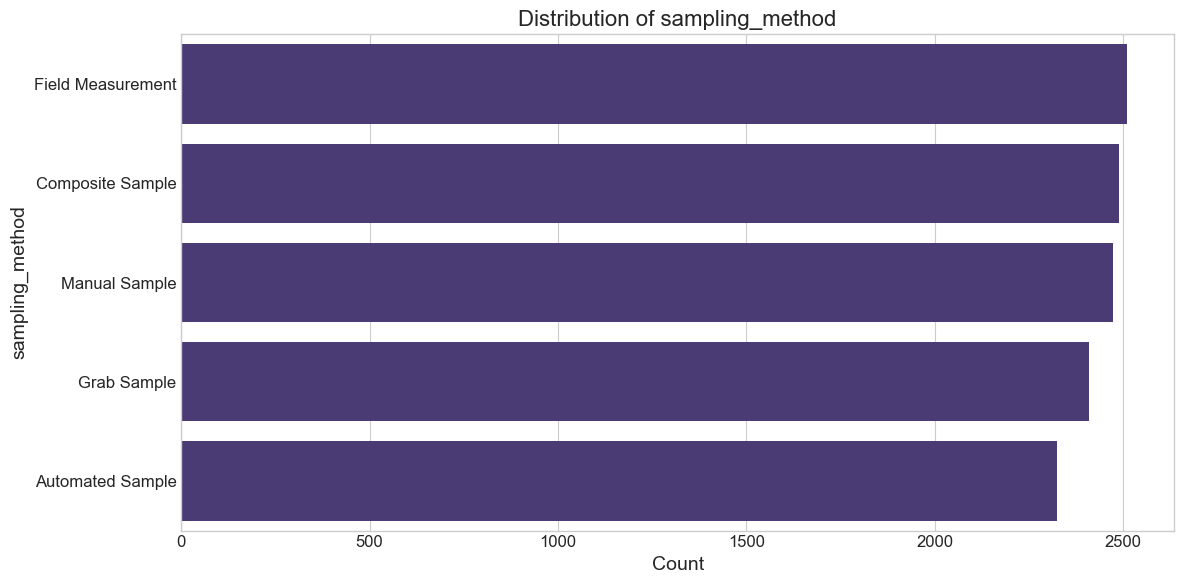


Distribution of param_category:
param_category
Other          4449
Heavy Metal    2490
Common Ion     1572
Metal          1103
Nutrient        460
Name: count, dtype: int64


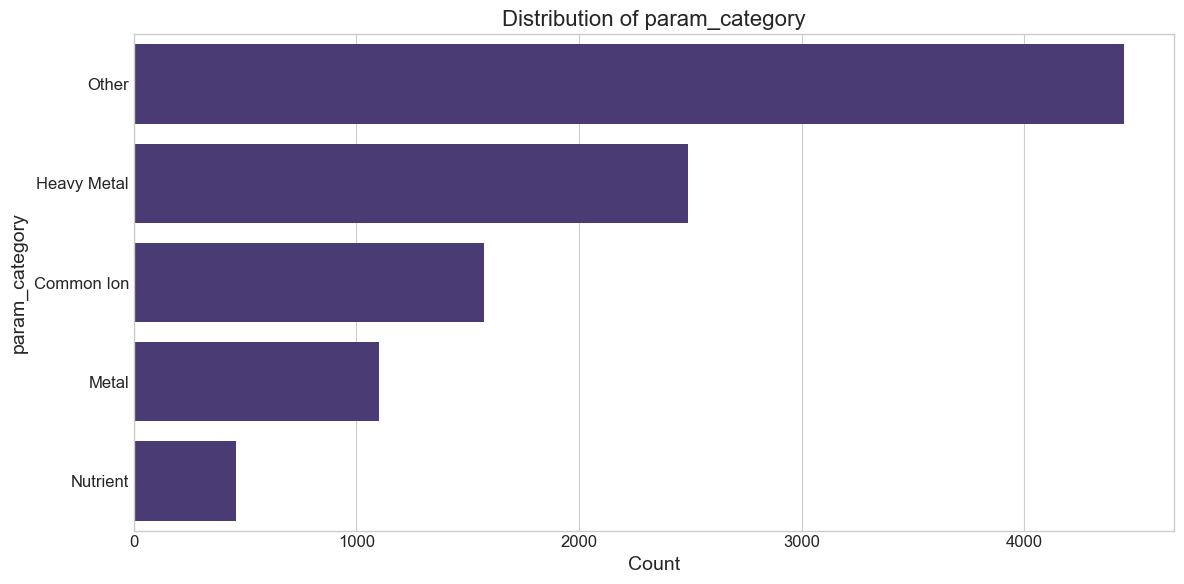


Distribution of pollution_risk:
pollution_risk
Low         3558
Medium      2266
Very Low    1788
High         588
Name: count, dtype: int64


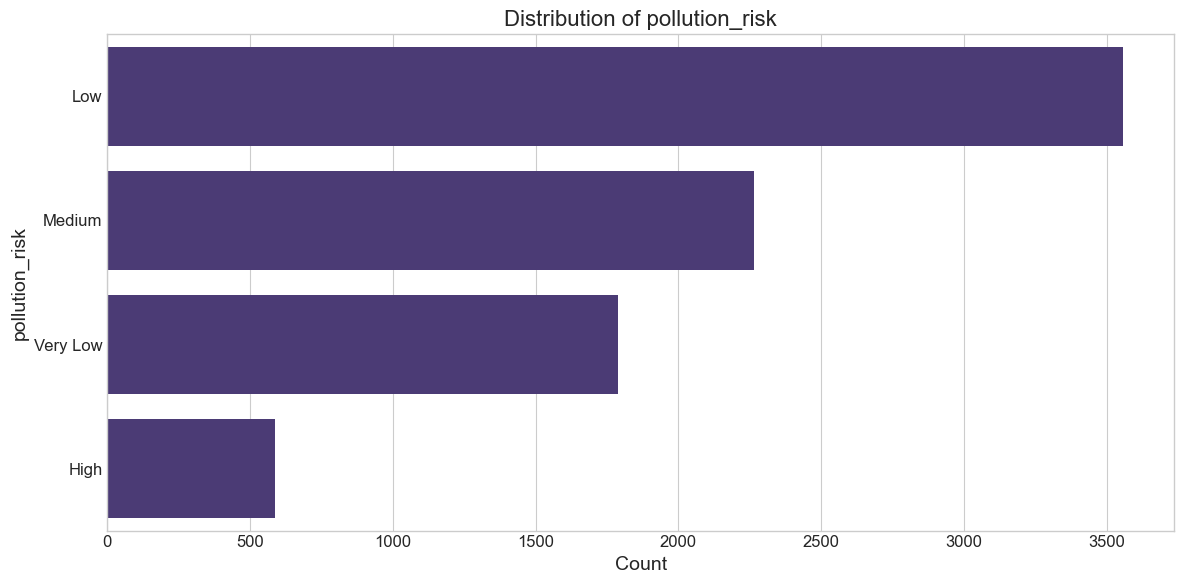


Distribution of Data Quality:
Data Quality
Fair              10133
Unknown            3590
Good                251
Pending review       24
Name: count, dtype: int64


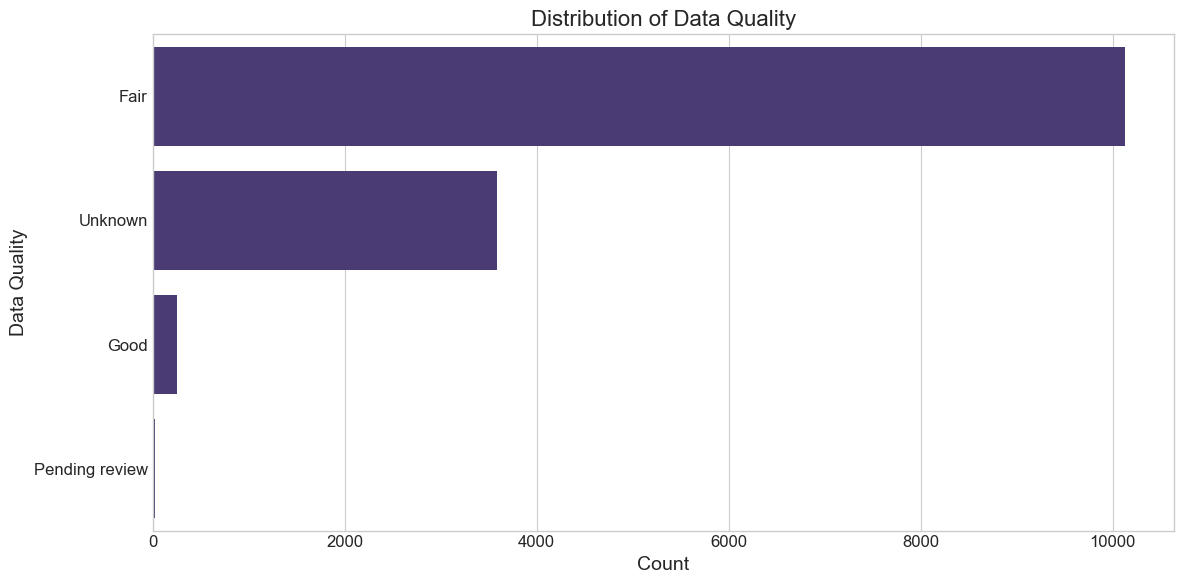


Distribution of land_use_impact:
land_use_impact
Mixed Land Use           3185
Forest Dominant          3162
Urban Dominant           3118
Agricultural Dominant    3060
Name: count, dtype: int64


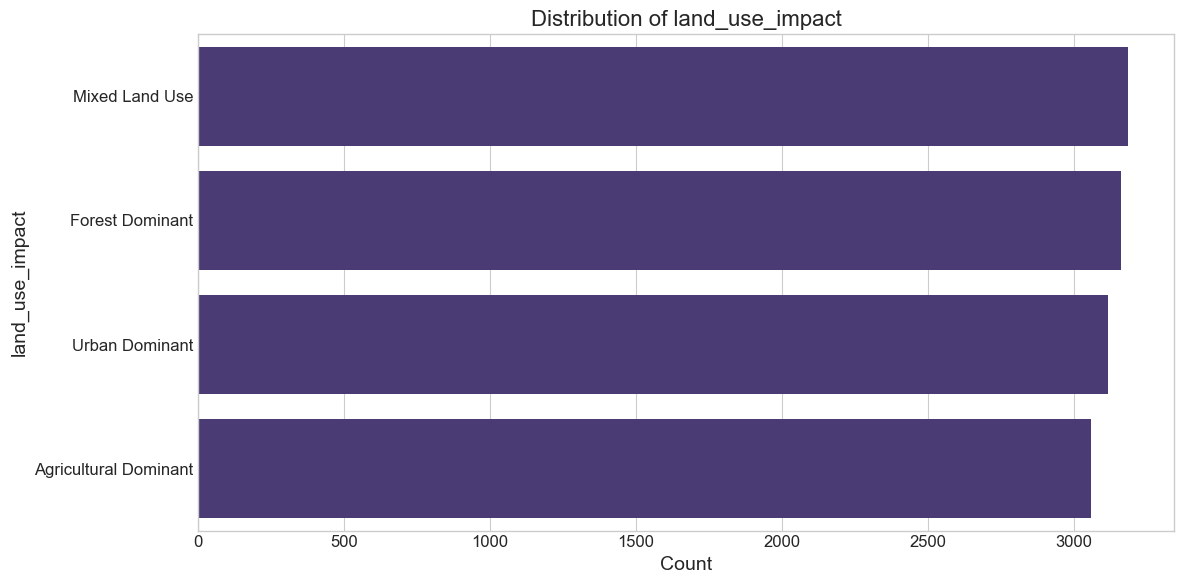


Distribution of is_referenced_method:
is_referenced_method
True     6517
False    6368
Name: count, dtype: int64


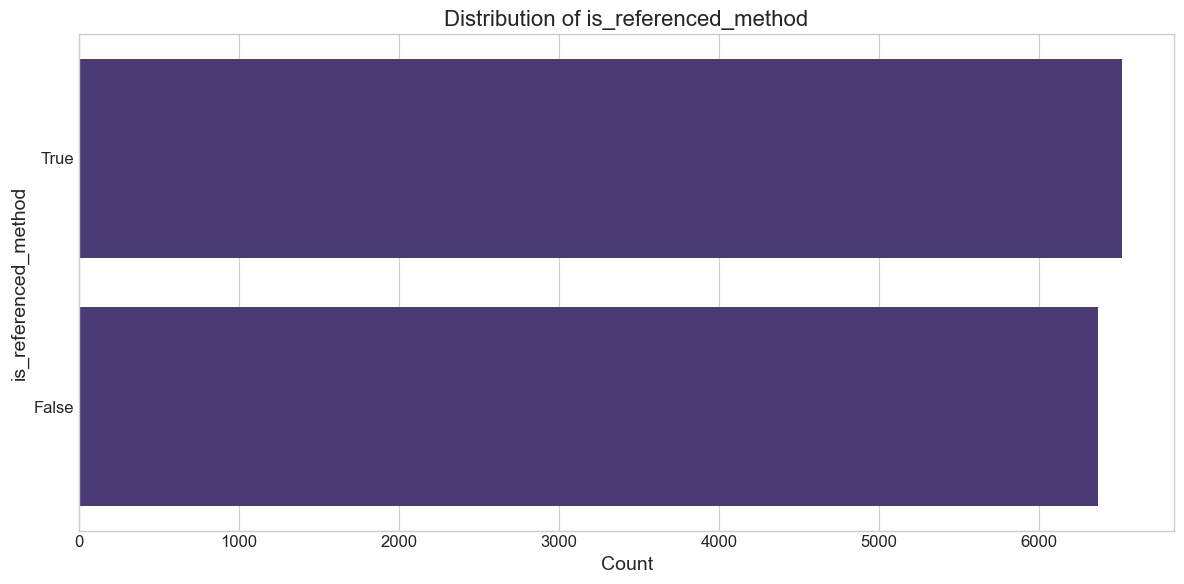


Distribution of validated_results:
validated_results
True     10208
False     2450
Name: count, dtype: int64


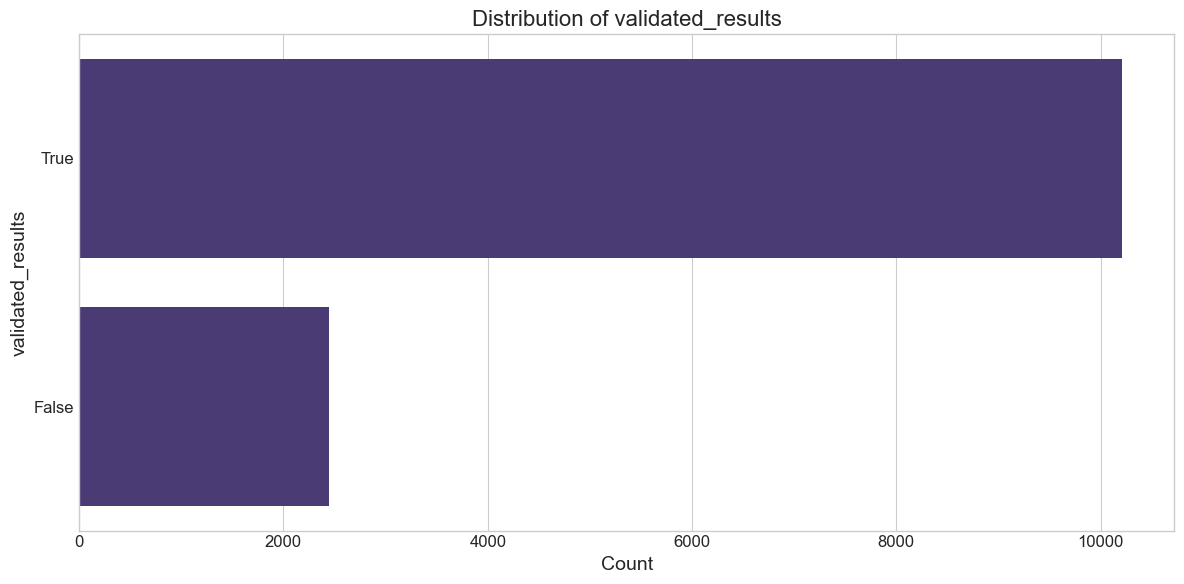


Distribution of Value Flags:
Value Flags
<    2040
>     130
Name: count, dtype: int64


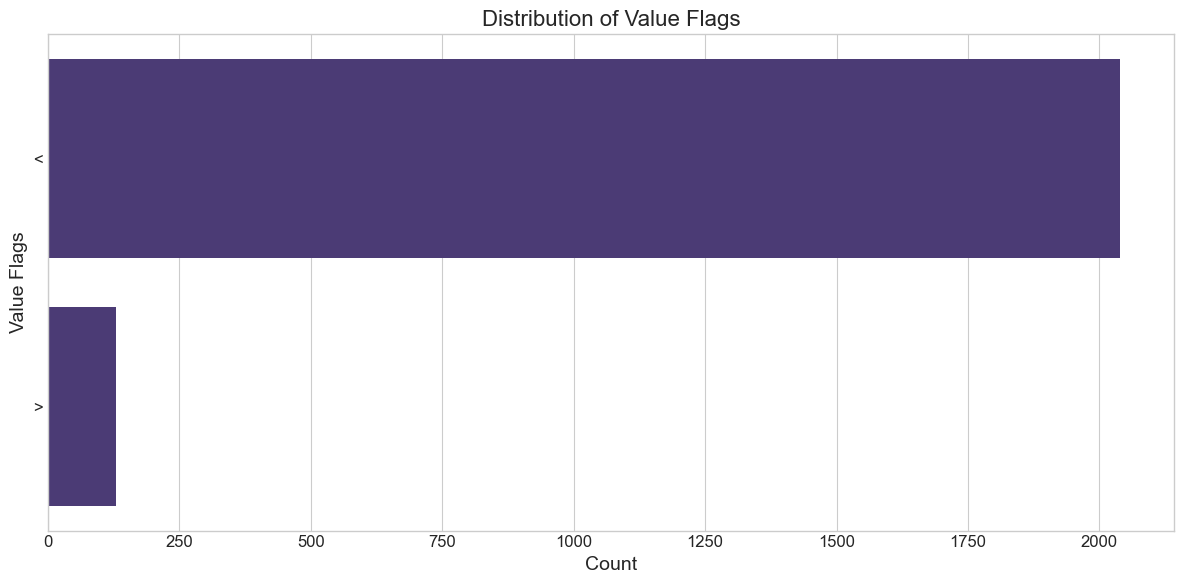

In [ ]:
# For features with reasonable cardinality, display value distributions
for feature in cat_unique_counts[cat_unique_counts < 10].index:
    print(f"\nDistribution of {feature}:")
    value_counts = train[feature].value_counts().sort_values(ascending=False)
    print(value_counts)
    # Visualize
    plt.figure(figsize=(12, 6))
    sns.countplot(y=feature, data=train, order=value_counts.index)
    plt.title(f'Distribution of {feature}', fontsize=16)
    plt.ylabel(feature, fontsize=14)
    plt.xlabel('Count', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'../reports/figures/{feature}_distribution.png', bbox_inches='tight')
    plt.show()


Relationship between categorical features and target:

Cross-tabulation of Value Flags and Data Quality:
Data Quality   Fair  Good  Pending review  Unknown
Value Flags                                       
<            87.304 0.637           0.637   11.422
>            96.154 0.000           0.000    3.846


<Figure size 1400x800 with 0 Axes>

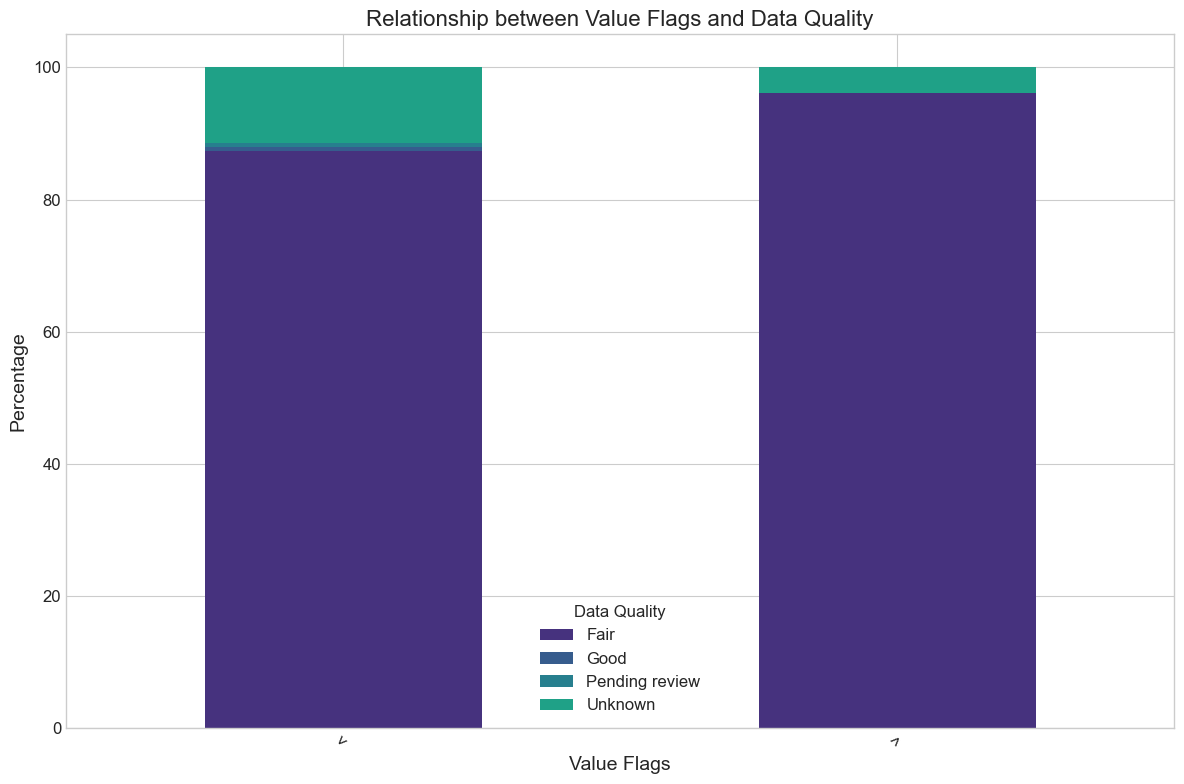


Cross-tabulation of Data Quality and Data Quality:
Data Quality      Fair    Good  Pending review  Unknown
Data Quality                                           
Fair           100.000   0.000           0.000    0.000
Good             0.000 100.000           0.000    0.000
Pending review   0.000   0.000         100.000    0.000
Unknown          0.000   0.000           0.000  100.000


<Figure size 1400x800 with 0 Axes>

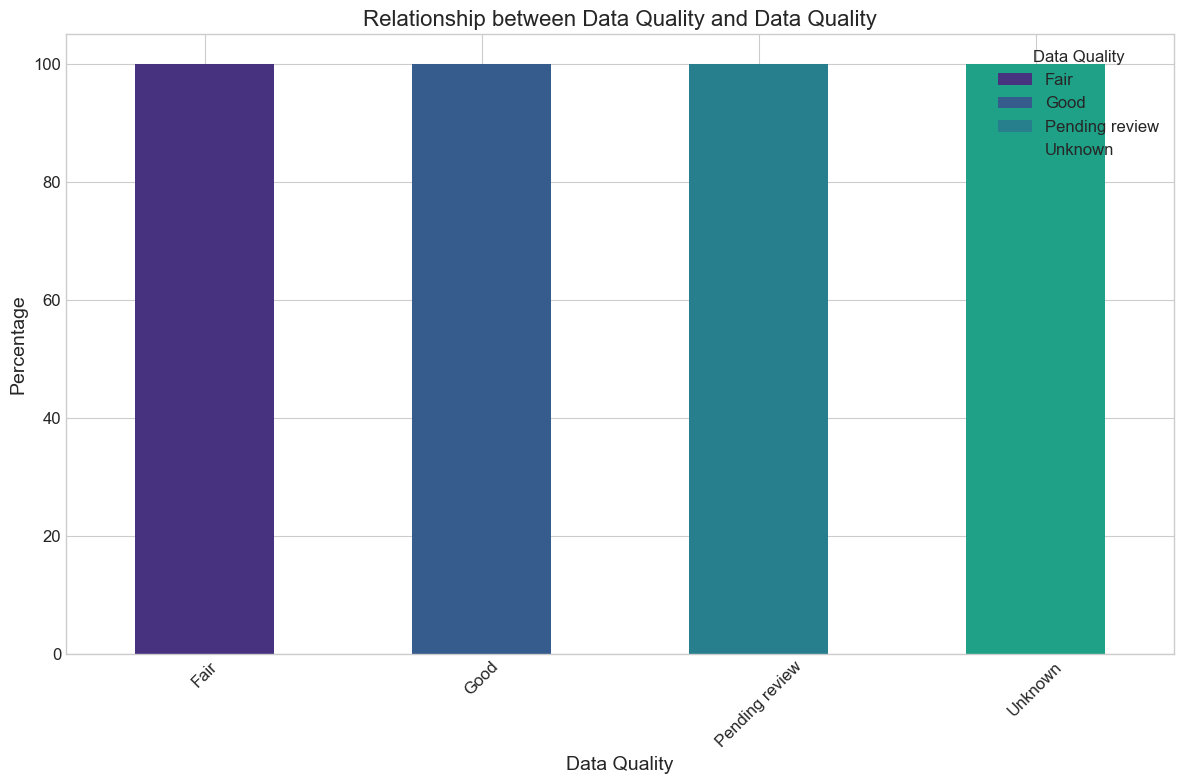

In [ ]:
# Analyzing relationship between categorical features and target
print("\nRelationship between categorical features and target:")
for feature in categorical_features[:min(5, len(categorical_features))]:
    if train[feature].nunique() < 15:  # Only for features with reasonable cardinality
        print(f"\nCross-tabulation of {feature} and Data Quality:")
        cross_tab = pd.crosstab(train[feature], train['Data Quality'], normalize='index') * 100
        print(cross_tab)
        
        # Stacked bar chart
        plt.figure(figsize=(14, 8))
        cross_tab.plot(kind='bar', stacked=True)
        plt.title(f'Relationship between {feature} and Data Quality', fontsize=16)
        plt.xlabel(feature, fontsize=14)
        plt.ylabel('Percentage', fontsize=14)
        plt.xticks(rotation=45)
        plt.legend(title='Data Quality')
        plt.tight_layout()
        plt.savefig(f'../reports/figures/{feature}_vs_target.png', bbox_inches='tight')
        plt.show()


Examining temporal patterns:


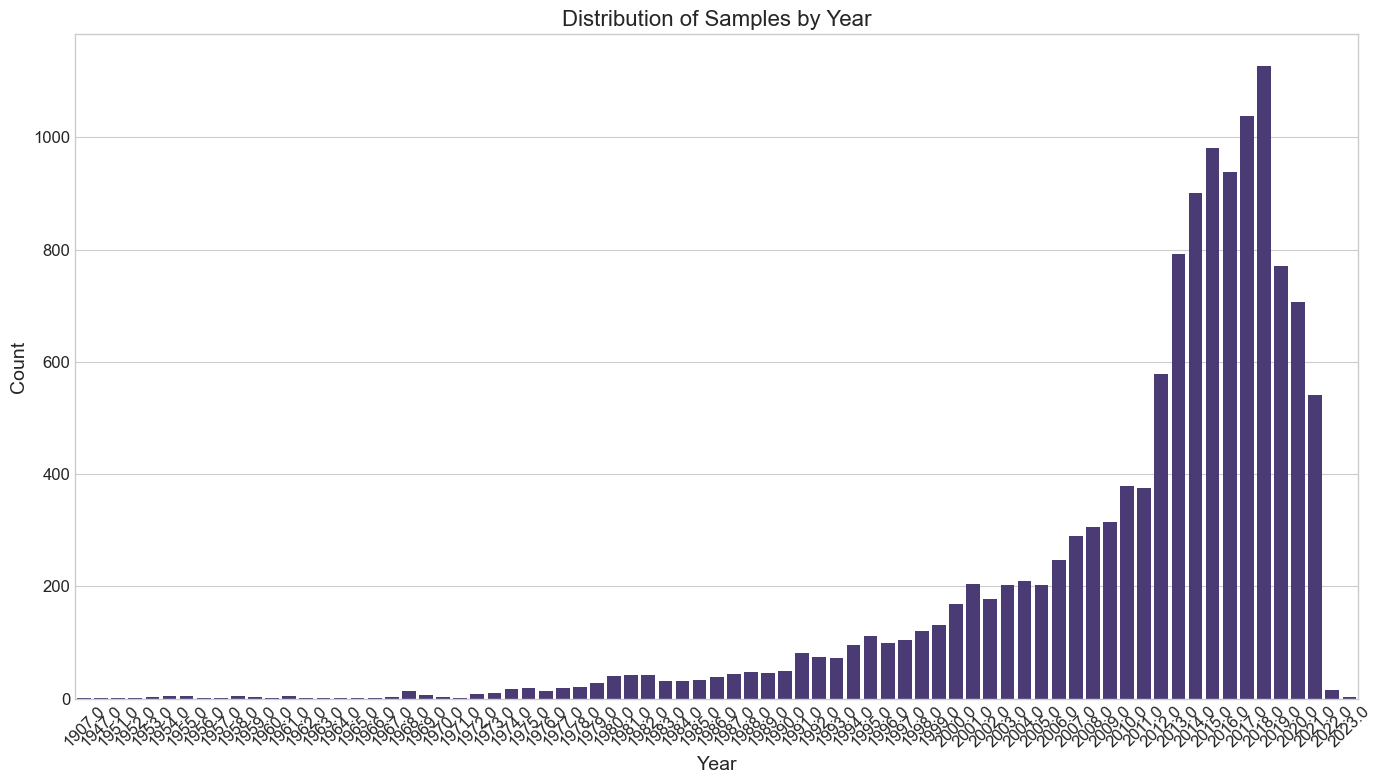

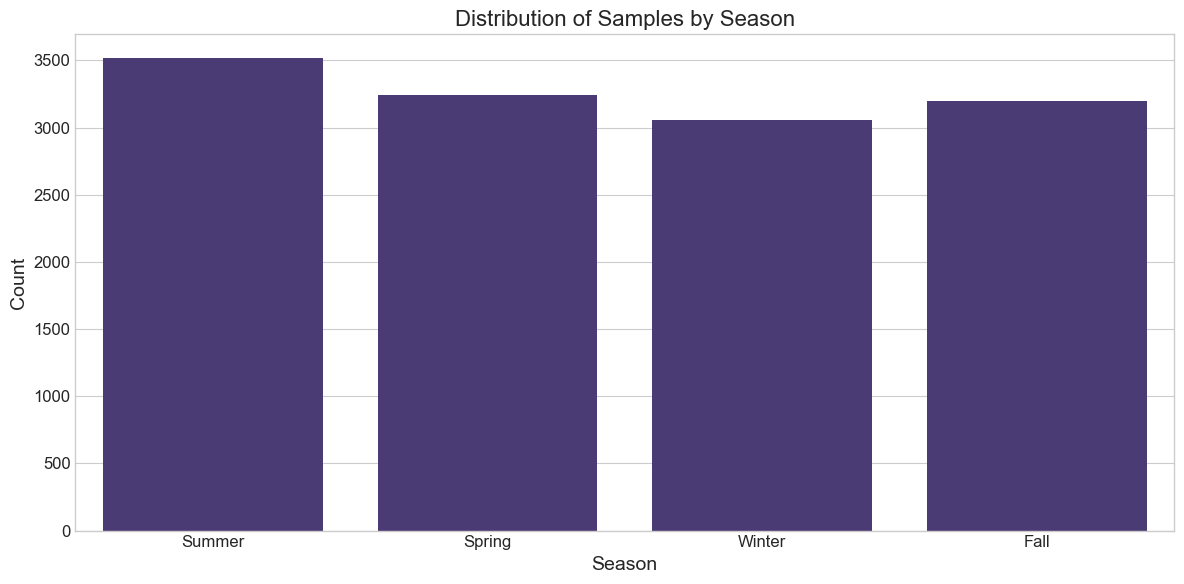

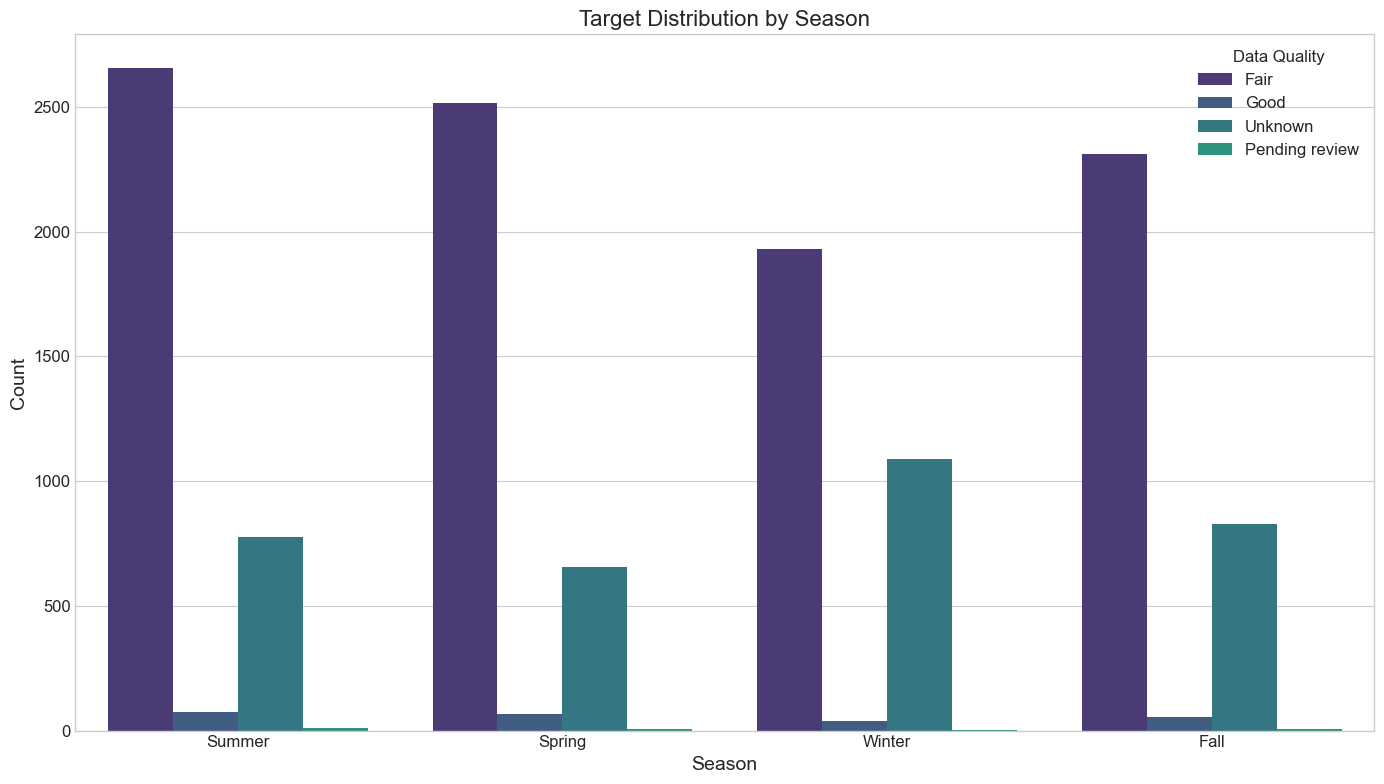

In [ ]:
# Analyzing temporal data
if 'time_season' in train.columns:
    print("\nExamining temporal patterns:")
    # Extract date and season
    train['date'] = train['time_season'].str.split(' - ').str[0]
    train['season'] = train['time_season'].str.split(' - ').str[1]
    
    # Convert date to datetime
    train['date'] = pd.to_datetime(train['date'], errors='coerce')
    
    # Extract year
    train['year'] = train['date'].dt.year
    
    # Check distribution by year
    plt.figure(figsize=(14, 8))
    sns.countplot(x='year', data=train)
    plt.title('Distribution of Samples by Year', fontsize=16)
    plt.xlabel('Year', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../reports/figures/year_distribution.png', bbox_inches='tight')
    plt.show()

    # Check distribution by season
    plt.figure(figsize=(12, 6))
    sns.countplot(x='season', data=train)
    plt.title('Distribution of Samples by Season', fontsize=16)
    plt.xlabel('Season', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.tight_layout()
    plt.savefig('../reports/figures/season_distribution.png', bbox_inches='tight')
    plt.show()
    
    # Check target distribution by season
    plt.figure(figsize=(14, 8))
    sns.countplot(x='season', hue='Data Quality', data=train)
    plt.title('Target Distribution by Season', fontsize=16)
    plt.xlabel('Season', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.legend(title='Data Quality')
    plt.tight_layout()
    plt.savefig('../reports/figures/target_by_season.png', bbox_inches='tight')
    plt.show()



Examining spatial patterns:


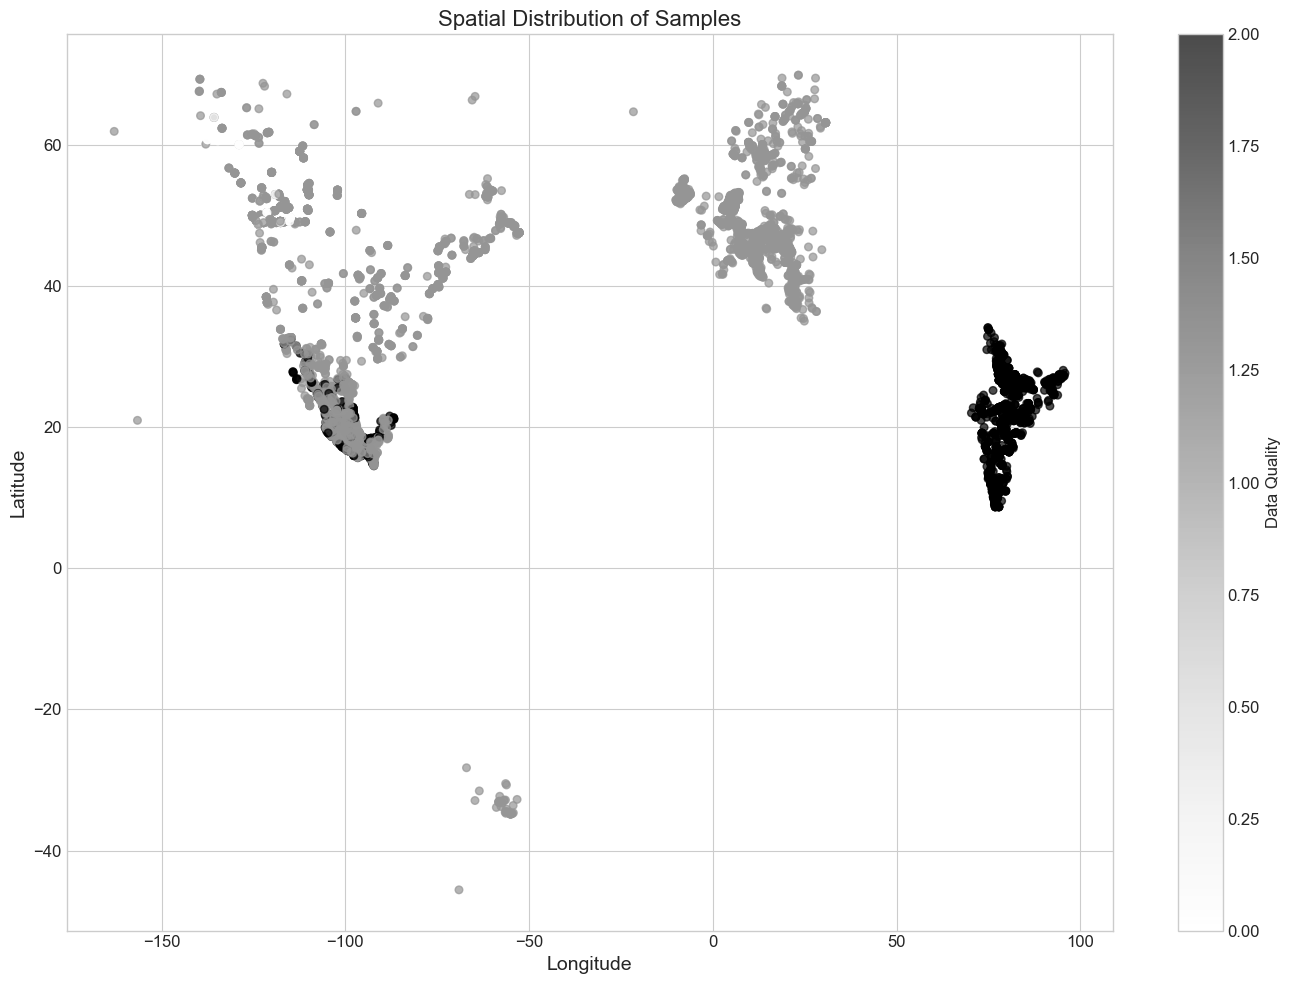

In [ ]:
# Analyzing spatial data
if 'Latitude' in train.columns and 'Longitude' in train.columns:
    print("\nExamining spatial patterns:")
    # Filter out rows with missing coordinates
    spatial_data = train.dropna(subset=['Latitude', 'Longitude'])
    
    plt.figure(figsize=(14, 10))
    plt.scatter(spatial_data['Longitude'], spatial_data['Latitude'], 
               c=spatial_data['Data Quality'].map({'Good': 0, 'Fair': 1, 'Unknown': 2, 'Pending Review': 3}),
               alpha=0.7, s=30)
    plt.colorbar(label='Data Quality')
    plt.title('Spatial Distribution of Samples', fontsize=16)
    plt.xlabel('Longitude', fontsize=14)
    plt.ylabel('Latitude', fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('../reports/figures/spatial_distribution.png', bbox_inches='tight')
    plt.show()


In [ ]:
# Feature correlations
print("\nAnalyzing correlations between numerical features:")
# Calculate correlations
correlation_matrix = train[numerical_features].corr()


Analyzing correlations between numerical features:


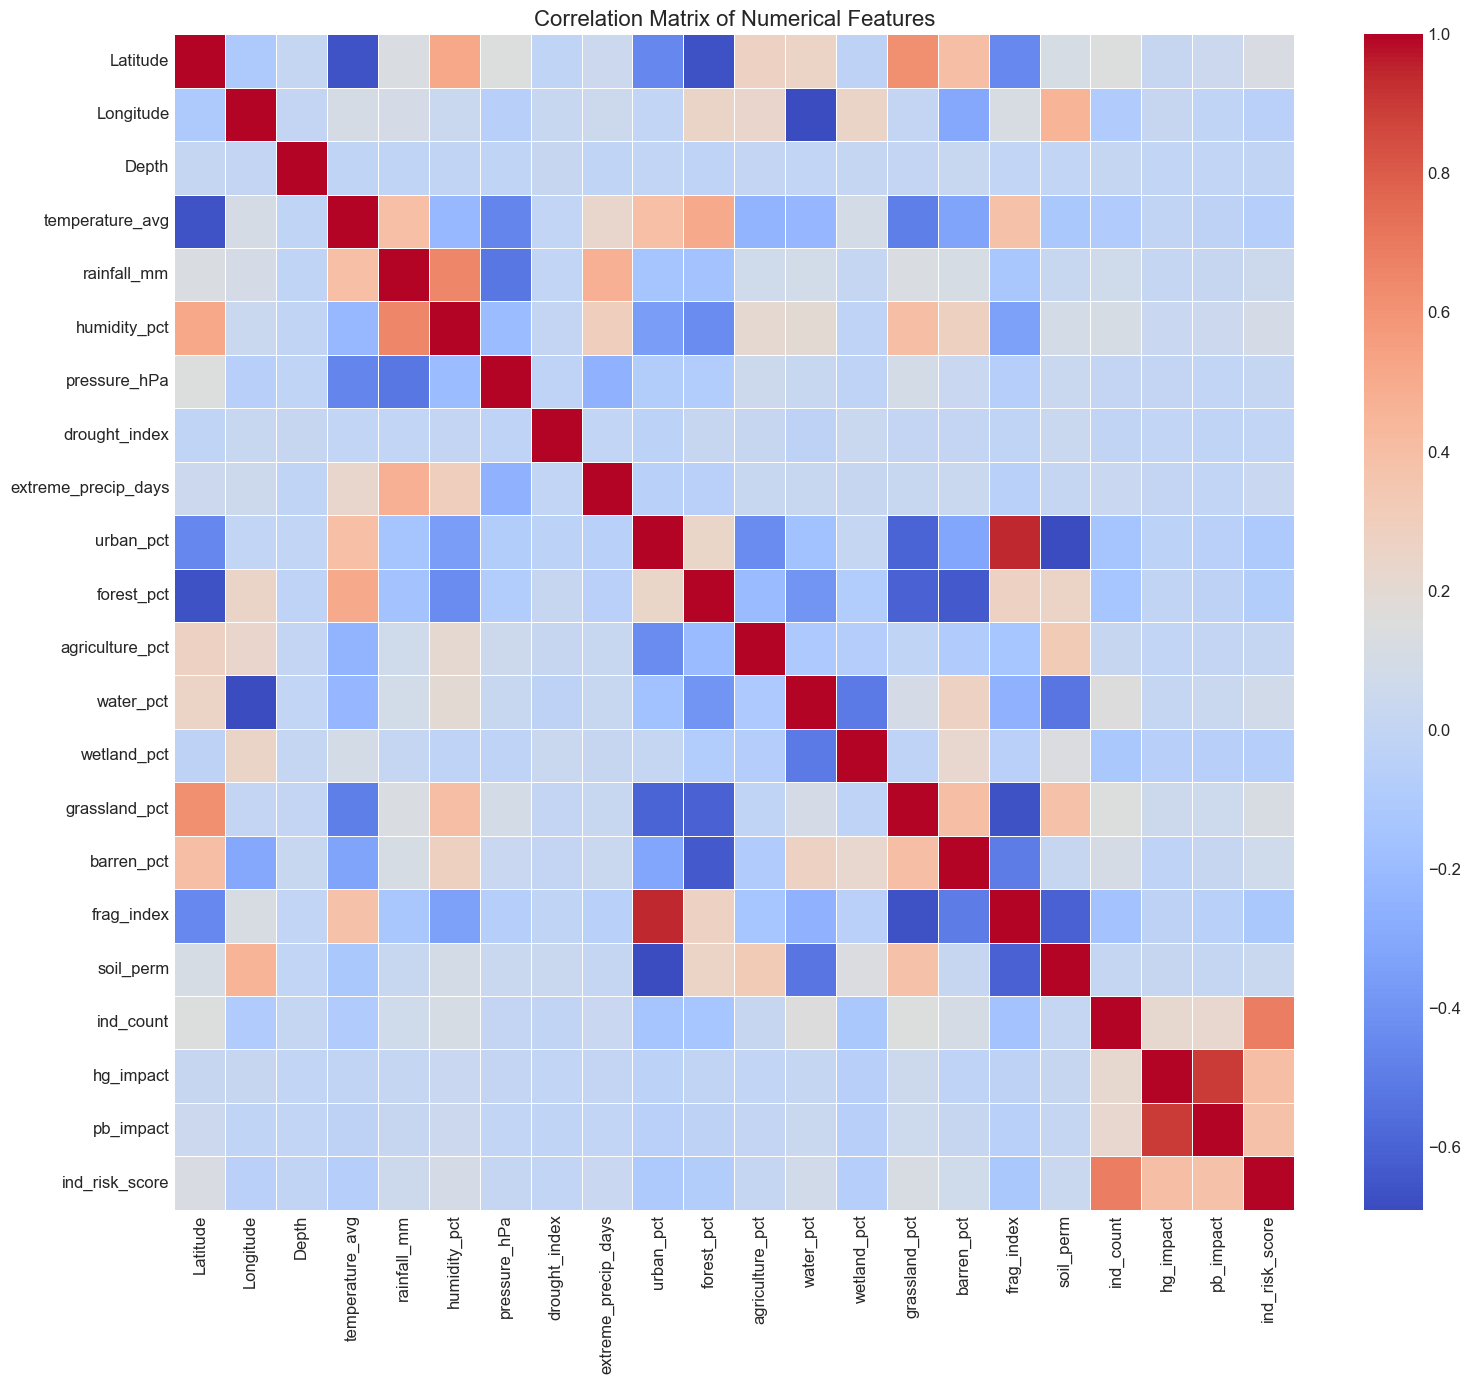

In [ ]:
# Plot heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/correlation_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
# Top correlated features
top_corr = correlation_matrix.unstack().sort_values(ascending=False)
top_corr = top_corr[top_corr < 1]  # Remove self-correlations
print("\nTop 10 correlated feature pairs:")
print(top_corr.head(10))


Top 10 correlated feature pairs:
frag_index      urban_pct        0.943
urban_pct       frag_index       0.943
pb_impact       hg_impact        0.897
hg_impact       pb_impact        0.897
ind_risk_score  ind_count        0.688
ind_count       ind_risk_score   0.688
rainfall_mm     humidity_pct     0.654
humidity_pct    rainfall_mm      0.654
Latitude        grassland_pct    0.621
grassland_pct   Latitude         0.621
dtype: float64



Analyzing parameter categories:
param_category
Other          4449
Heavy Metal    2490
Common Ion     1572
Metal          1103
Nutrient        460
Name: count, dtype: int64


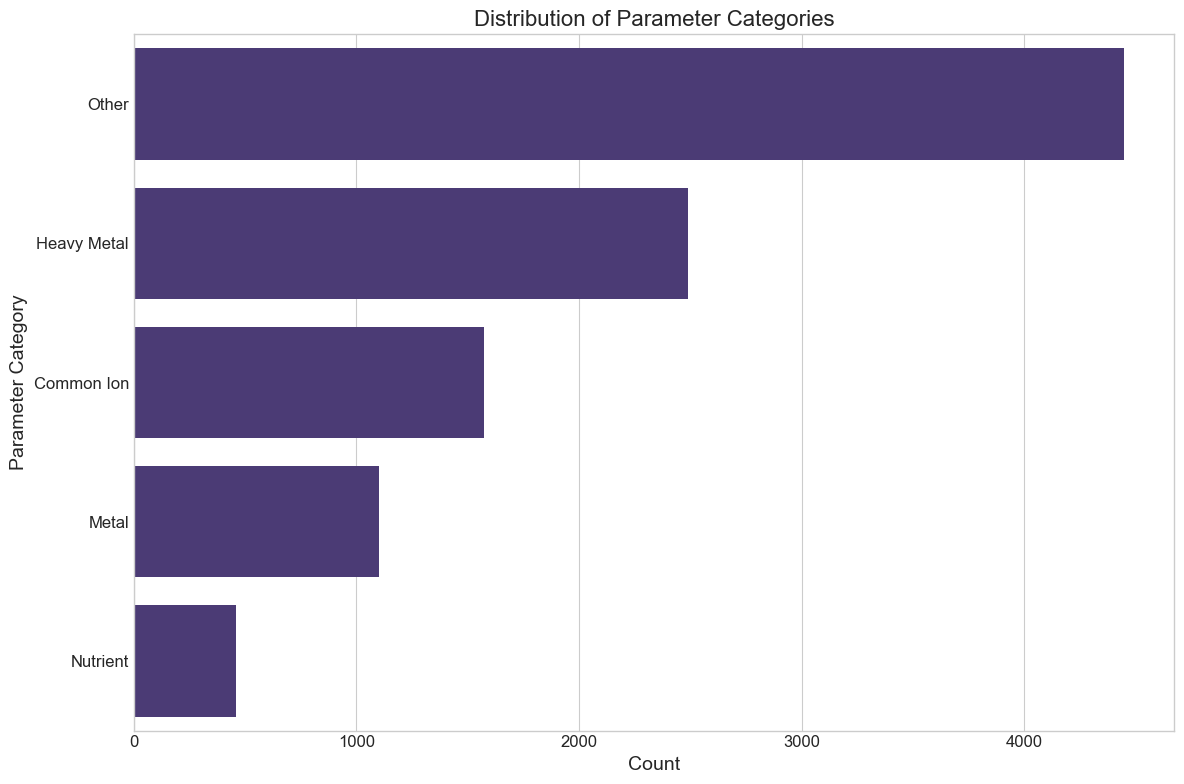

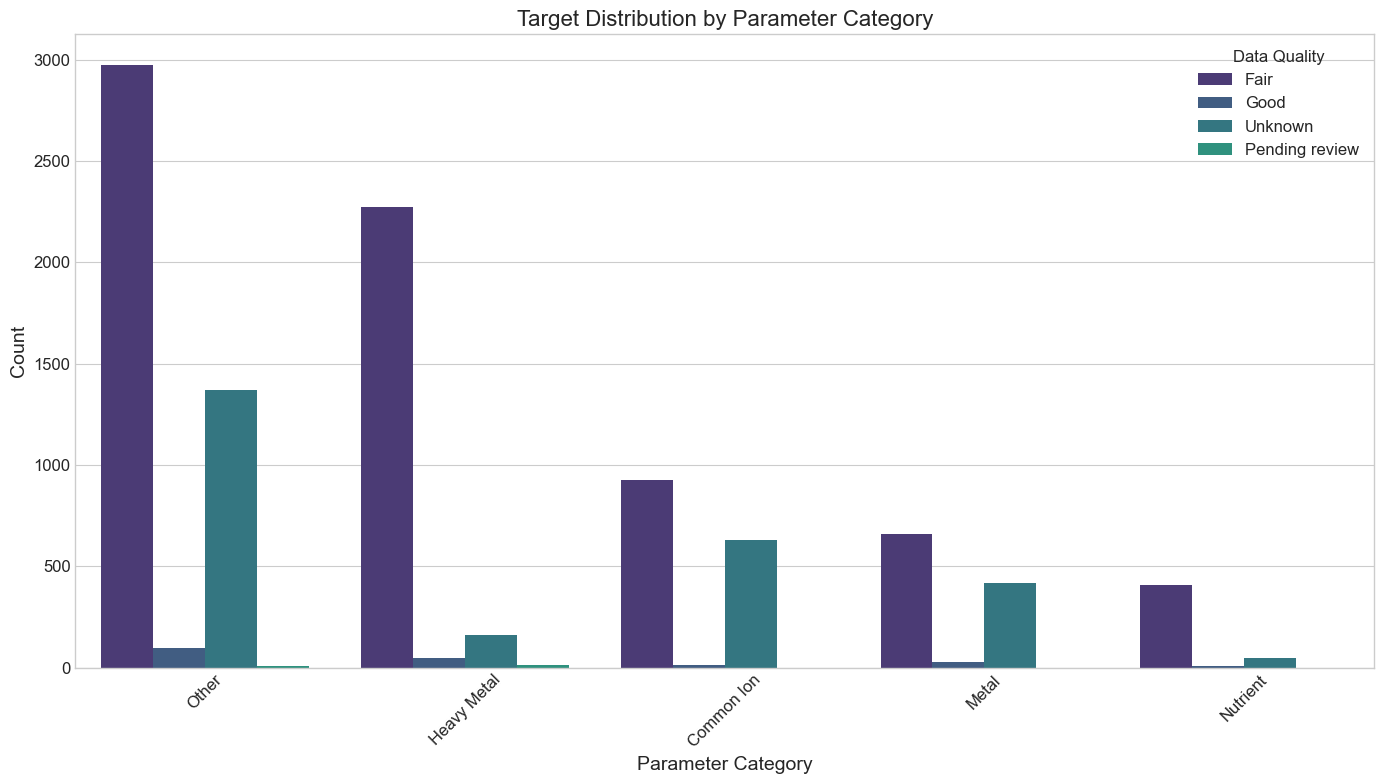

In [ ]:
# Analyze specific parameter categories
if 'param_category' in train.columns:
    print("\nAnalyzing parameter categories:")
    param_cat_counts = train['param_category'].value_counts()
    print(param_cat_counts)
    
    plt.figure(figsize=(12, 8))
    sns.countplot(y='param_category', data=train, order=param_cat_counts.index)
    plt.title('Distribution of Parameter Categories', fontsize=16)
    plt.ylabel('Parameter Category', fontsize=14)
    plt.xlabel('Count', fontsize=14)
    plt.tight_layout()
    plt.savefig('../reports/figures/param_category_distribution.png', bbox_inches='tight')
    plt.show()
    
    # Relationship with target
    plt.figure(figsize=(14, 8))
    sns.countplot(x='param_category', hue='Data Quality', data=train, order=param_cat_counts.index)
    plt.title('Target Distribution by Parameter Category', fontsize=16)
    plt.xlabel('Parameter Category', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.xticks(rotation=45)
    plt.legend(title='Data Quality')
    plt.tight_layout()
    plt.savefig('../reports/figures/target_by_param_category.png', bbox_inches='tight')
    plt.show()


Analyzing Value Flags:
Value Flags
NaN    11828
<       2040
>        130
Name: count, dtype: int64


<Figure size 1200x800 with 0 Axes>

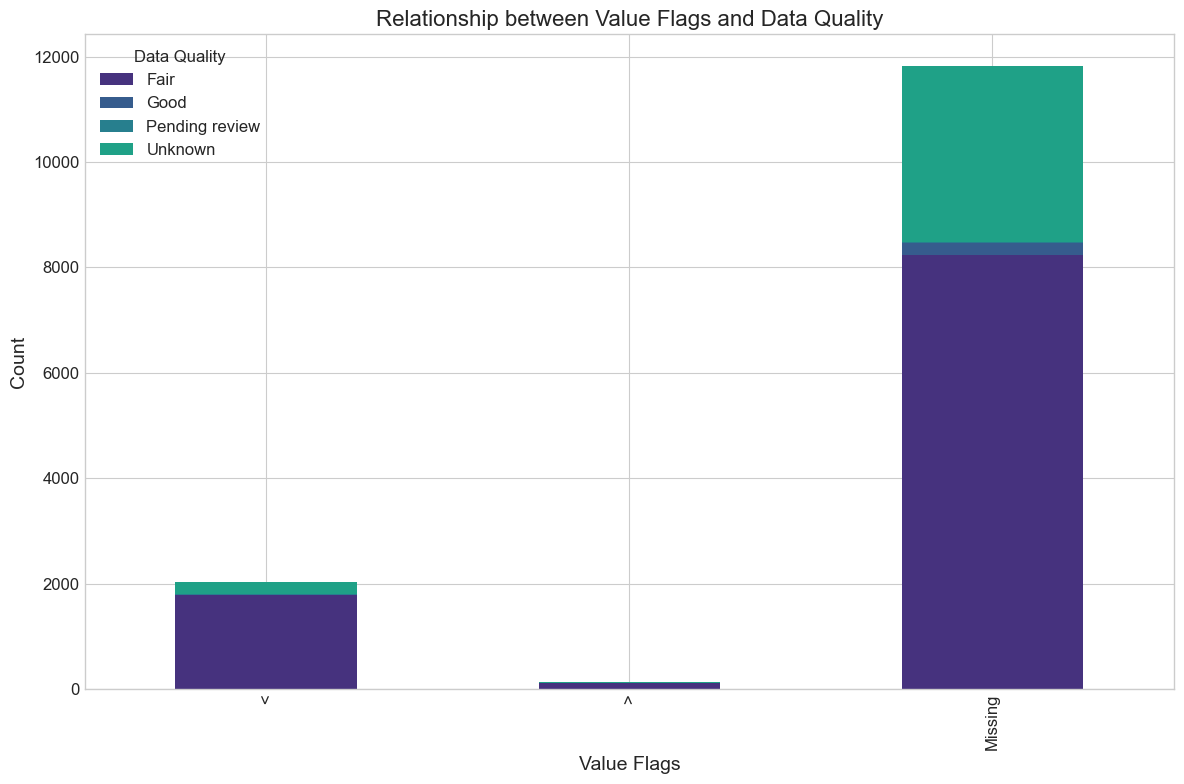

In [ ]:
# Look at value flags - often important in water quality data
if 'Value Flags' in train.columns:
    print("\nAnalyzing Value Flags:")
    value_flags_counts = train['Value Flags'].value_counts(dropna=False)
    print(value_flags_counts)
    
    # Relationship with target
    plt.figure(figsize=(12, 8))
    cross_tab = pd.crosstab(train['Value Flags'].fillna('Missing'), train['Data Quality'])
    cross_tab.plot(kind='bar', stacked=True)
    plt.title('Relationship between Value Flags and Data Quality', fontsize=16)
    plt.xlabel('Value Flags', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.legend(title='Data Quality')
    plt.tight_layout()
    plt.savefig('../reports/figures/value_flags_vs_target.png', bbox_inches='tight')
    plt.show()


Distribution by Country:
country_code
MEX    2421
IND    2046
CAN    1594
USA     552
ITA     530
NLD     494
SWE     257
FRA     212
IRL     212
AUT     167
SRB     144
GRC     141
BEL     139
FIN     118
NOR      89
HUN      86
HRV      76
URY      64
CHE      48
MKD      46
POL      26
CZE      19
LTU      18
ROU      11
ARG      11
SVN       9
LVA       8
ESP       7
GBR       7
EST       6
DNK       4
BGR       2
ISL       1
PRT       1
Name: count, dtype: int64


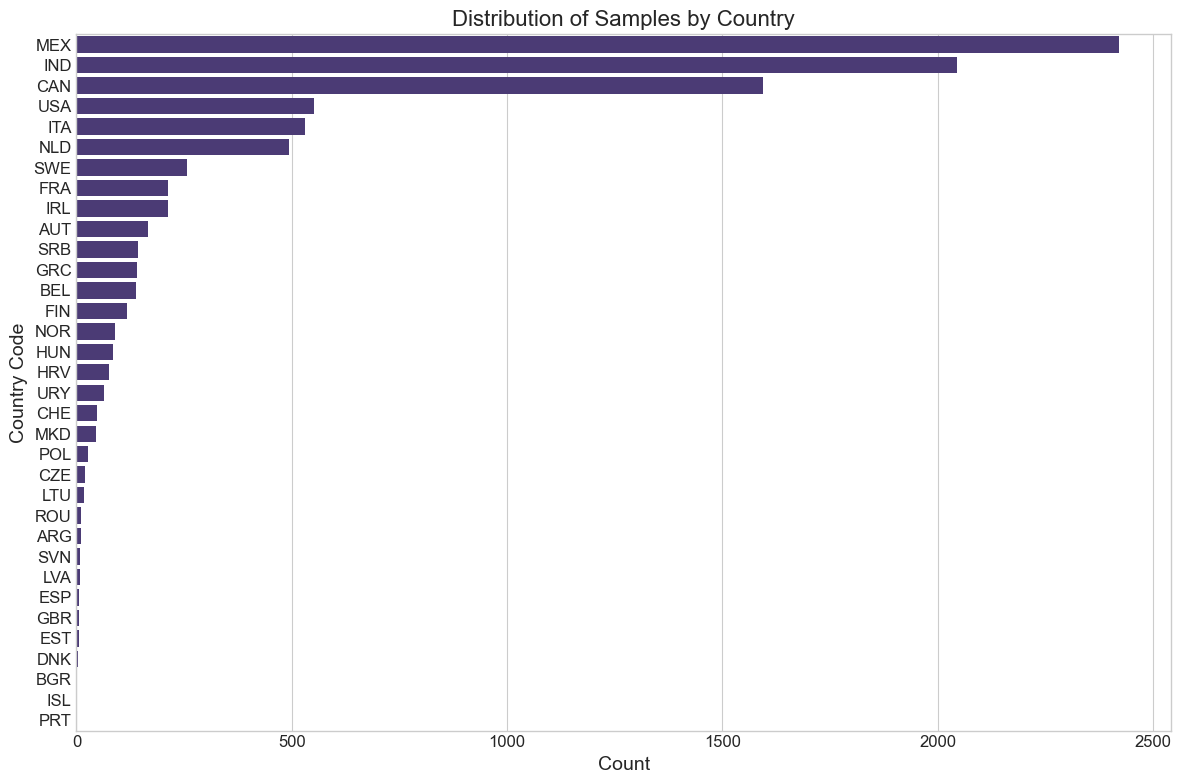

<Figure size 1400x1000 with 0 Axes>

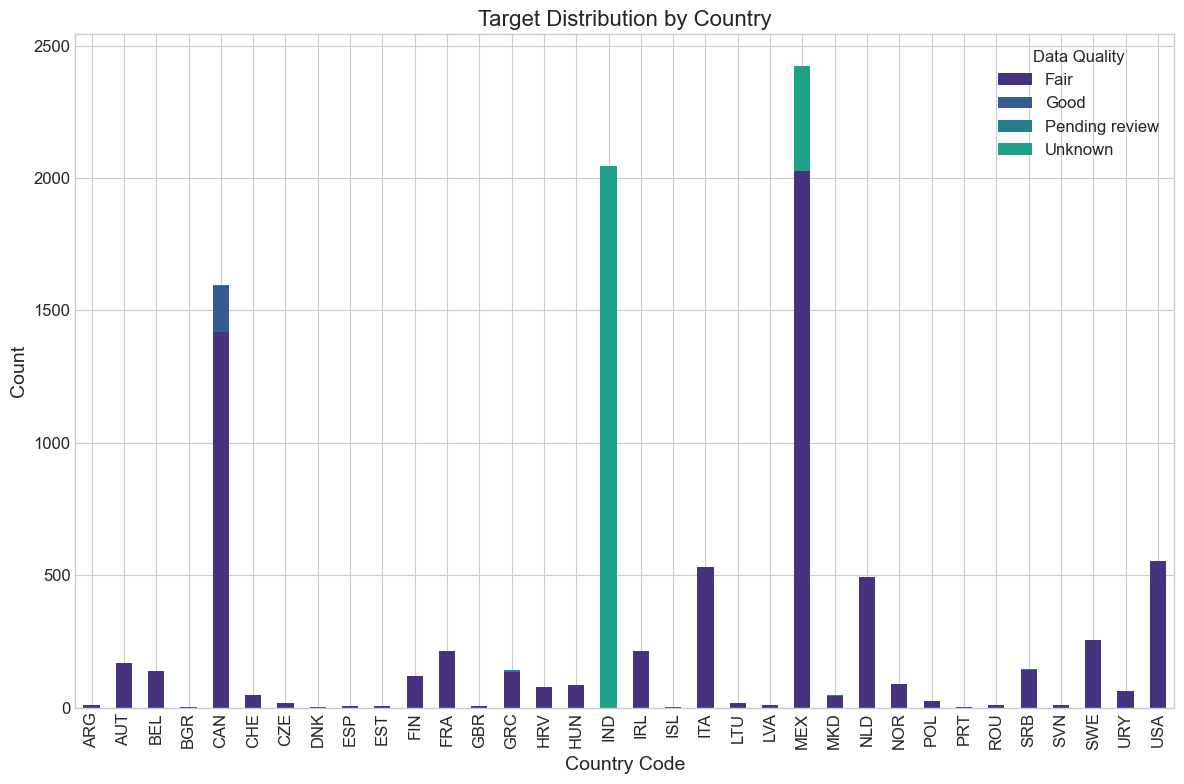

In [ ]:
# Look at country distribution
if 'country_code' in train.columns:
    print("\nDistribution by Country:")
    country_counts = train['country_code'].value_counts()
    print(country_counts)
    
    plt.figure(figsize=(12, 8))
    sns.countplot(y='country_code', data=train, order=country_counts.index)
    plt.title('Distribution of Samples by Country', fontsize=16)
    plt.ylabel('Country Code', fontsize=14)
    plt.xlabel('Count', fontsize=14)
    plt.tight_layout()
    plt.savefig('../reports/figures/country_distribution.png', bbox_inches='tight')
    plt.show()
    
    # Target distribution by country
    plt.figure(figsize=(14, 10))
    cross_tab = pd.crosstab(train['country_code'], train['Data Quality'])
    cross_tab.plot(kind='bar', stacked=True)
    plt.title('Target Distribution by Country', fontsize=16)
    plt.xlabel('Country Code', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.legend(title='Data Quality')
    plt.tight_layout()
    plt.savefig('../reports/figures/target_by_country.png', bbox_inches='tight')
    plt.show()


Analyzing land use percentages:


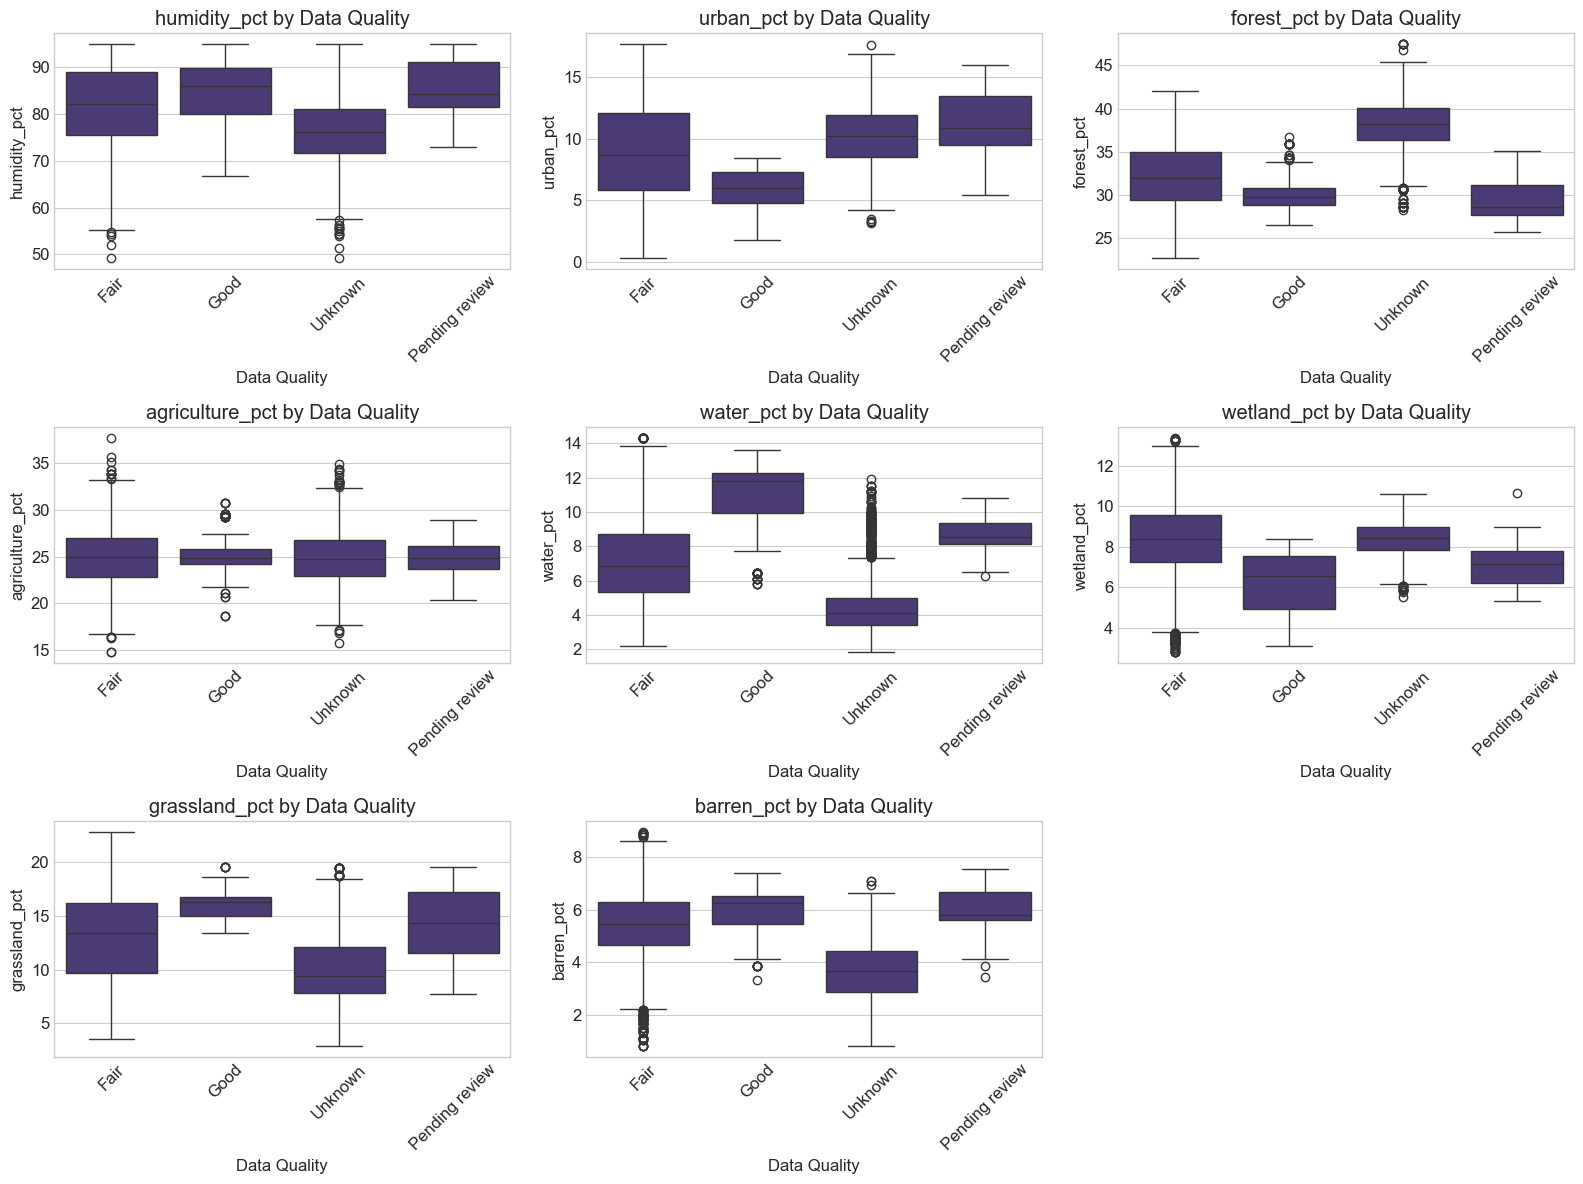


Average land use percentages by target:
                humidity_pct  urban_pct  forest_pct  agriculture_pct  \
Data Quality                                                           
Fair                  81.880      8.892      32.120           24.930   
Good                  85.262      5.678      30.274           25.108   
Pending review        85.632     11.156      29.250           24.565   
Unknown               76.587     10.249      38.071           24.925   

                water_pct  wetland_pct  grassland_pct  barren_pct  
Data Quality                                                       
Fair                7.255        8.325         13.002       5.473  
Good               10.856        6.286         15.935       5.873  
Pending review      8.565        7.258         14.131       5.835  
Unknown             4.482        8.373         10.202       3.698  


<Figure size 1200x800 with 0 Axes>

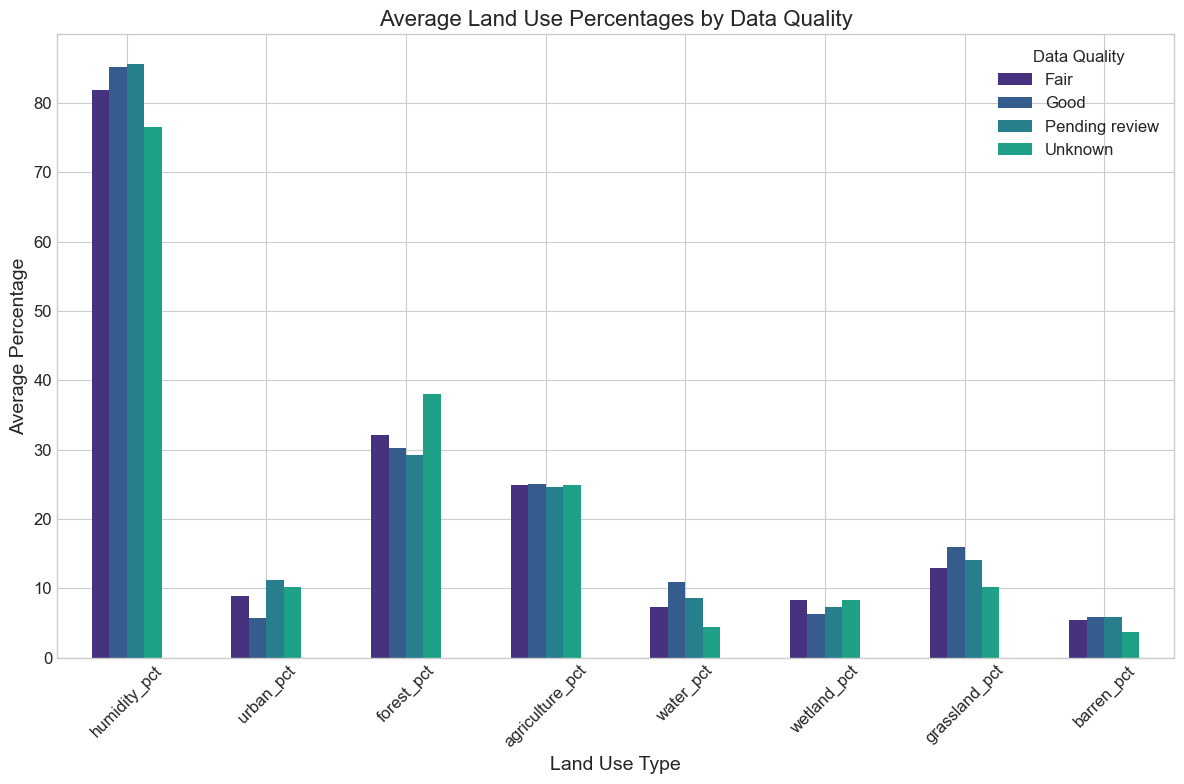

In [ ]:
# Analyzing land use percentages
land_use_cols = [col for col in train.columns if col.endswith('_pct')]
if land_use_cols:
    print("\nAnalyzing land use percentages:")
    
    # Create boxplots for land use percentages by target
    plt.figure(figsize=(16, 12))
    for i, col in enumerate(land_use_cols):
        plt.subplot(3, 3, i+1)
        sns.boxplot(x='Data Quality', y=col, data=train)
        plt.title(f'{col} by Data Quality')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../reports/figures/land_use_by_target.png', bbox_inches='tight')
    plt.show()
    
    # Average land use by target
    land_use_by_target = train.groupby('Data Quality')[land_use_cols].mean()
    print("\nAverage land use percentages by target:")
    print(land_use_by_target)
    
    # Stacked area chart of average land use
    plt.figure(figsize=(12, 8))
    land_use_by_target.T.plot(kind='bar', stacked=False)
    plt.title('Average Land Use Percentages by Data Quality', fontsize=16)
    plt.xlabel('Land Use Type', fontsize=14)
    plt.ylabel('Average Percentage', fontsize=14)
    plt.xticks(rotation=45)
    plt.legend(title='Data Quality')
    plt.tight_layout()
    plt.savefig('../reports/figures/avg_land_use_by_target.png', bbox_inches='tight')
    plt.show()


Analyzing impact and risk scores:


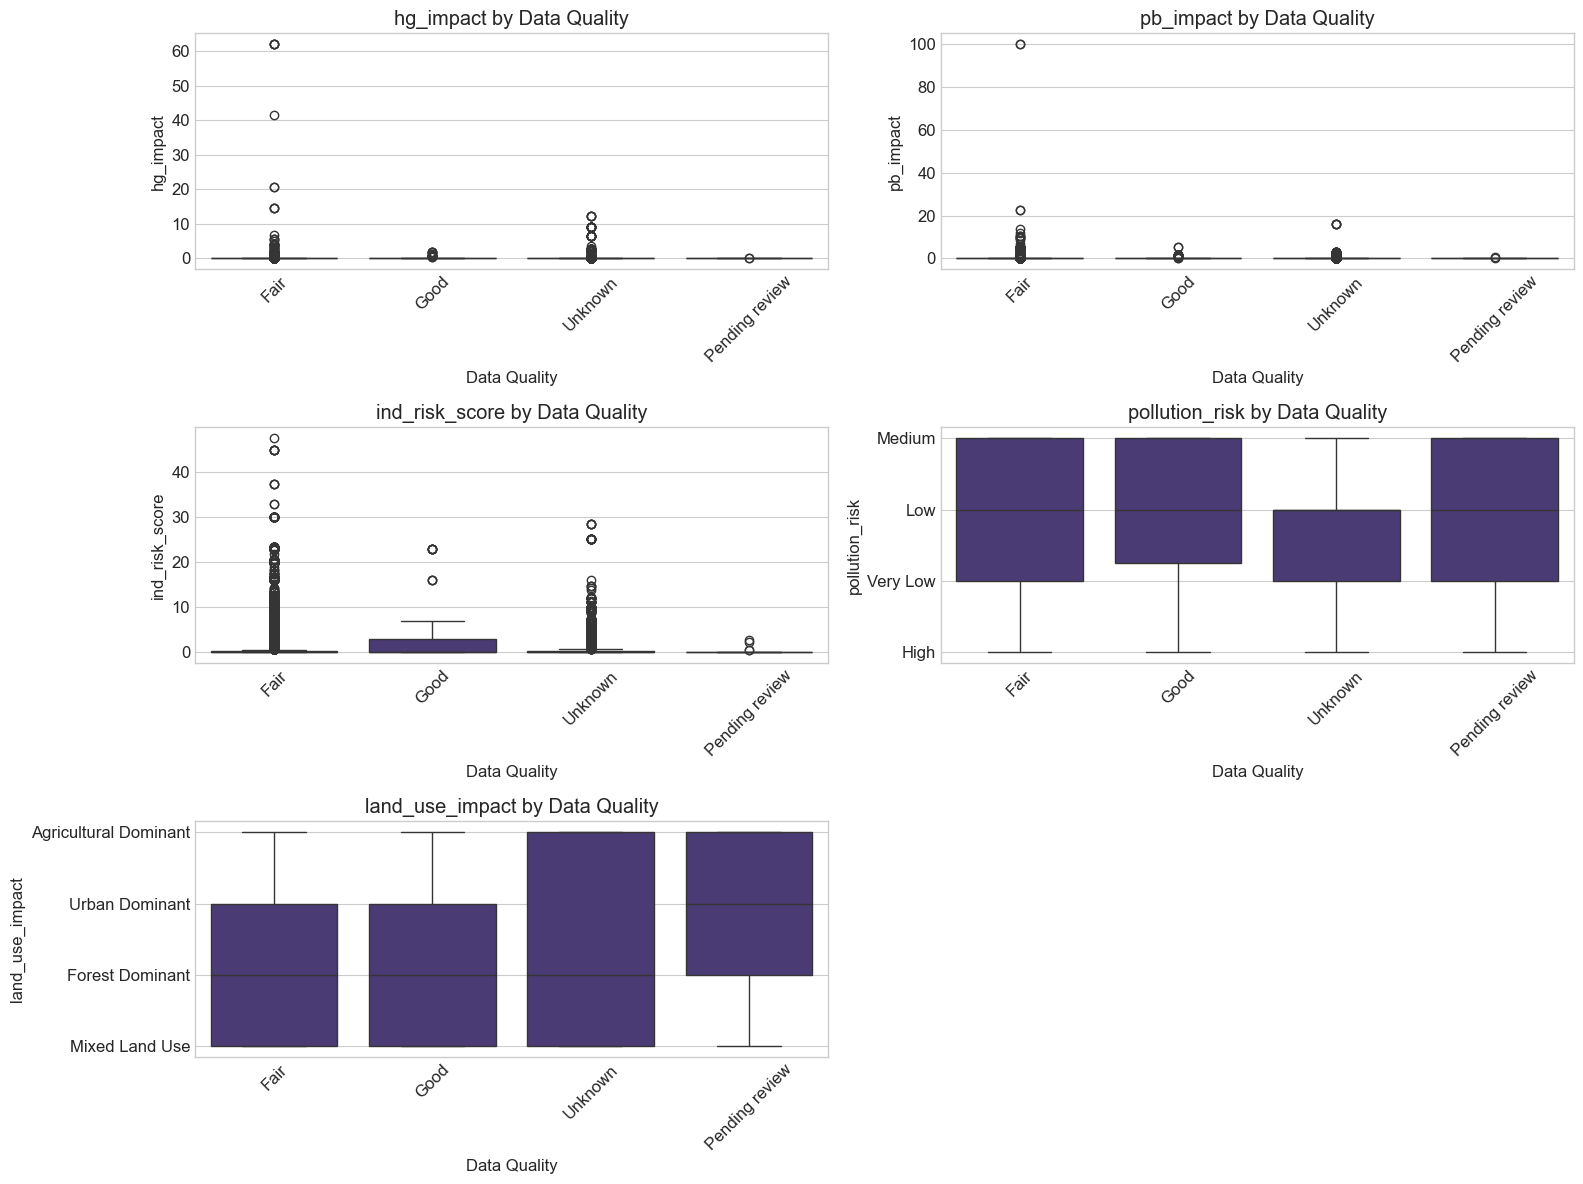

In [ ]:
# Analyzing impact and risk scores
impact_risk_cols = [col for col in train.columns if 'impact' in col or 'risk' in col]
if impact_risk_cols:
    print("\nAnalyzing impact and risk scores:")
    
    # Boxplots for impact/risk scores by target
    plt.figure(figsize=(16, 12))
    for i, col in enumerate(impact_risk_cols):
        plt.subplot(3, 2, i+1)  # Adjusted to 3 rows and 2 columns to fit 5 plots
        sns.boxplot(x='Data Quality', y=col, data=train)
        plt.title(f'{col} by Data Quality')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../reports/figures/impact_risk_by_target.png', bbox_inches='tight')
    plt.show()


Analyzing impact and risk scores:


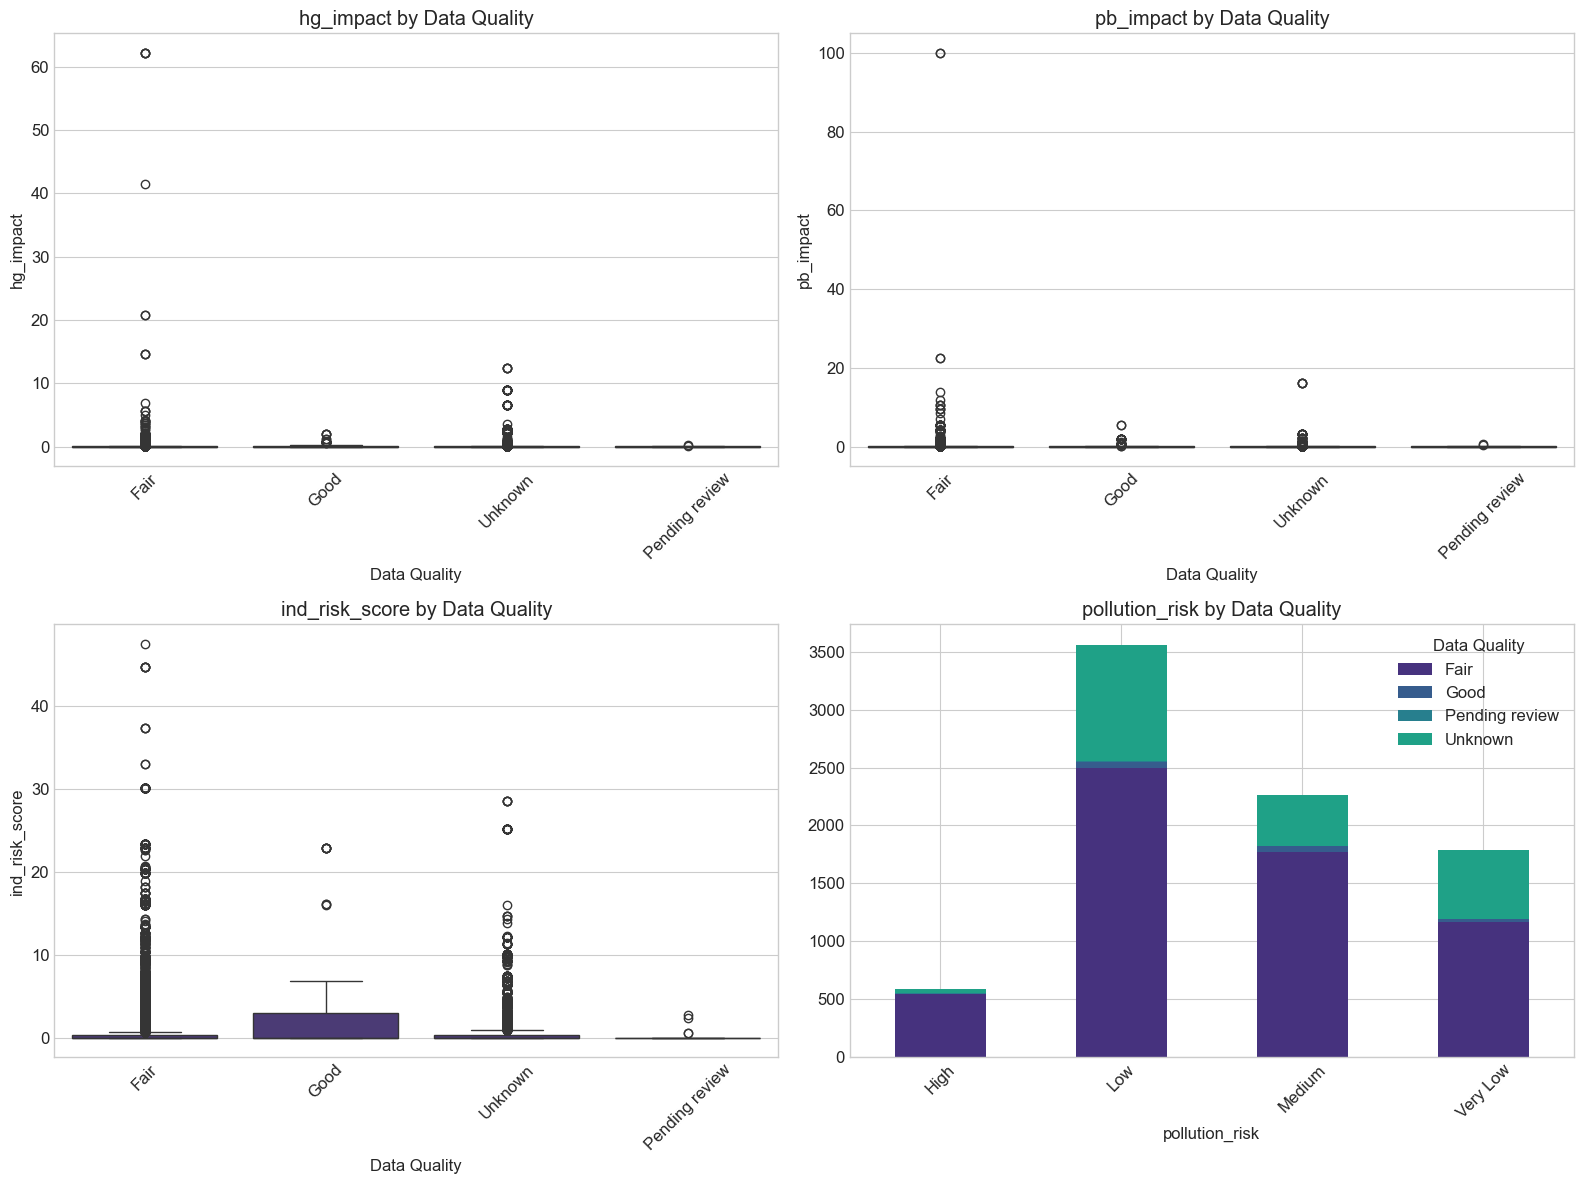


Features most correlated with hg_impact:
pb_impact        0.897
ind_risk_score   0.399
ind_count        0.218
wetland_pct      0.057
grassland_pct    0.055
humidity_pct     0.031
urban_pct        0.030
frag_index       0.028
soil_perm        0.022
Longitude        0.019
Name: hg_impact, dtype: float64

Features most correlated with pb_impact:
hg_impact        0.897
ind_risk_score   0.385
ind_count        0.223
wetland_pct      0.058
grassland_pct    0.057
frag_index       0.055
urban_pct        0.048
humidity_pct     0.046
Latitude         0.044
water_pct        0.039
Name: pb_impact, dtype: float64

Features most correlated with ind_risk_score:
ind_count       0.688
hg_impact       0.399
pb_impact       0.385
Latitude        0.126
frag_index      0.117
grassland_pct   0.116
urban_pct       0.106
humidity_pct    0.096
forest_pct      0.083
water_pct       0.081
Name: ind_risk_score, dtype: float64


In [ ]:
# Analyzing impact and risk scores
impact_risk_cols = [col for col in train.columns if 'impact' in col or 'risk' in col]
numerical_impact_risk_cols = [col for col in impact_risk_cols if col in numerical_features]

if impact_risk_cols:
    print("\nAnalyzing impact and risk scores:")
    
    # Boxplots for impact/risk scores by target (all - numerical and categorical)
    plt.figure(figsize=(16, 12))
    for i, col in enumerate(impact_risk_cols[:4]):  # Limit to 4 subplots
        plt.subplot(2, 2, i+1)
        if col in numerical_features:
            sns.boxplot(x='Data Quality', y=col, data=train)
        else:
            # For categorical risk features, use count plot
            ax = plt.subplot(2, 2, i+1)
            counts = pd.crosstab(train[col], train['Data Quality'])
            counts.plot(kind='bar', stacked=True, ax=ax)
        plt.title(f'{col} by Data Quality')
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../reports/figures/impact_risk_by_target.png', bbox_inches='tight')
    plt.show()
    
    # Correlations only for numerical impact/risk features
    if numerical_impact_risk_cols:
        for col in numerical_impact_risk_cols:
            # Sort correlations by absolute value
            col_corr = correlation_matrix[col].abs().sort_values(ascending=False)
            print(f"\nFeatures most correlated with {col}:")
            # Print top 10 correlations excluding self-correlation
            print(col_corr[col_corr.index != col].head(10))

In [ ]:
# Checking for duplicate data
print("\n" + "="*50)
print("CHECKING FOR DUPLICATE DATA")
print("="*50)

# Check for exact duplicates in train data
train_duplicates = train.duplicated().sum()
print(f"\nExact duplicates in train data: {train_duplicates}")

# Check for duplicates based on specific columns (excluding target)
# Let's exclude the target and any ID columns
cols_to_check = [col for col in train.columns if col != 'Data Quality' and not col.endswith('_id')]
train_feature_duplicates = train.duplicated(subset=cols_to_check).sum()
print(f"Feature-based duplicates in train data: {train_feature_duplicates}")

if train_feature_duplicates > 0:
    # Show some examples of duplicated rows
    duplicated_indices = train.duplicated(subset=cols_to_check, keep=False)
    duplicate_examples = train[duplicated_indices].sort_values(by=cols_to_check).head(10)
    print("\nExamples of duplicate rows (based on features):")
    print(duplicate_examples)

# Check for duplicates in test data
test_duplicates = test.duplicated().sum()
print(f"\nExact duplicates in test data: {test_duplicates}")

test_feature_duplicates = test.duplicated(subset=[col for col in test.columns if col != 'id']).sum()
print(f"Feature-based duplicates in test data: {test_feature_duplicates}")


CHECKING FOR DUPLICATE DATA

Exact duplicates in train data: 0
Feature-based duplicates in train data: 0

Exact duplicates in test data: 0
Feature-based duplicates in test data: 0



OUTLIER ANALYSIS

Outlier analysis for numerical features:

Top 10 features with most outliers:
ind_risk_score:
  - Outliers: 2553.0 (18.24%)
  - Bounds: [-0.5276, 0.8794]
  - Actual range: [0.0000, 47.5131]
hg_impact:
  - Outliers: 2050.0 (14.64%)
  - Bounds: [-0.0311, 0.0518]
  - Actual range: [0.0000, 62.1468]
pb_impact:
  - Outliers: 1694.0 (12.10%)
  - Bounds: [-0.0367, 0.0611]
  - Actual range: [0.0000, 100.0000]
Depth:
  - Outliers: 1658.0 (11.84%)
  - Bounds: [0.3000, 0.3000]
  - Actual range: [0.0000, 300.0000]
wetland_pct:
  - Outliers: 379.0 (2.71%)
  - Bounds: [4.6295, 12.0345]
  - Actual range: [2.7671, 13.3656]
Latitude:
  - Outliers: 83.0 (0.59%)
  - Bounds: [-20.2362, 90.7793]
  - Actual range: [-51.6883, 81.8429]
agriculture_pct:
  - Outliers: 49.0 (0.35%)
  - Bounds: [16.9206, 32.8899]
  - Actual range: [14.7731, 37.6268]
pressure_hPa:
  - Outliers: 31.0 (0.22%)
  - Bounds: [998.1463, 1018.7115]
  - Actual range: [995.4175, 1022.1125]
water_pct:
  - Outliers: 31.0 (0

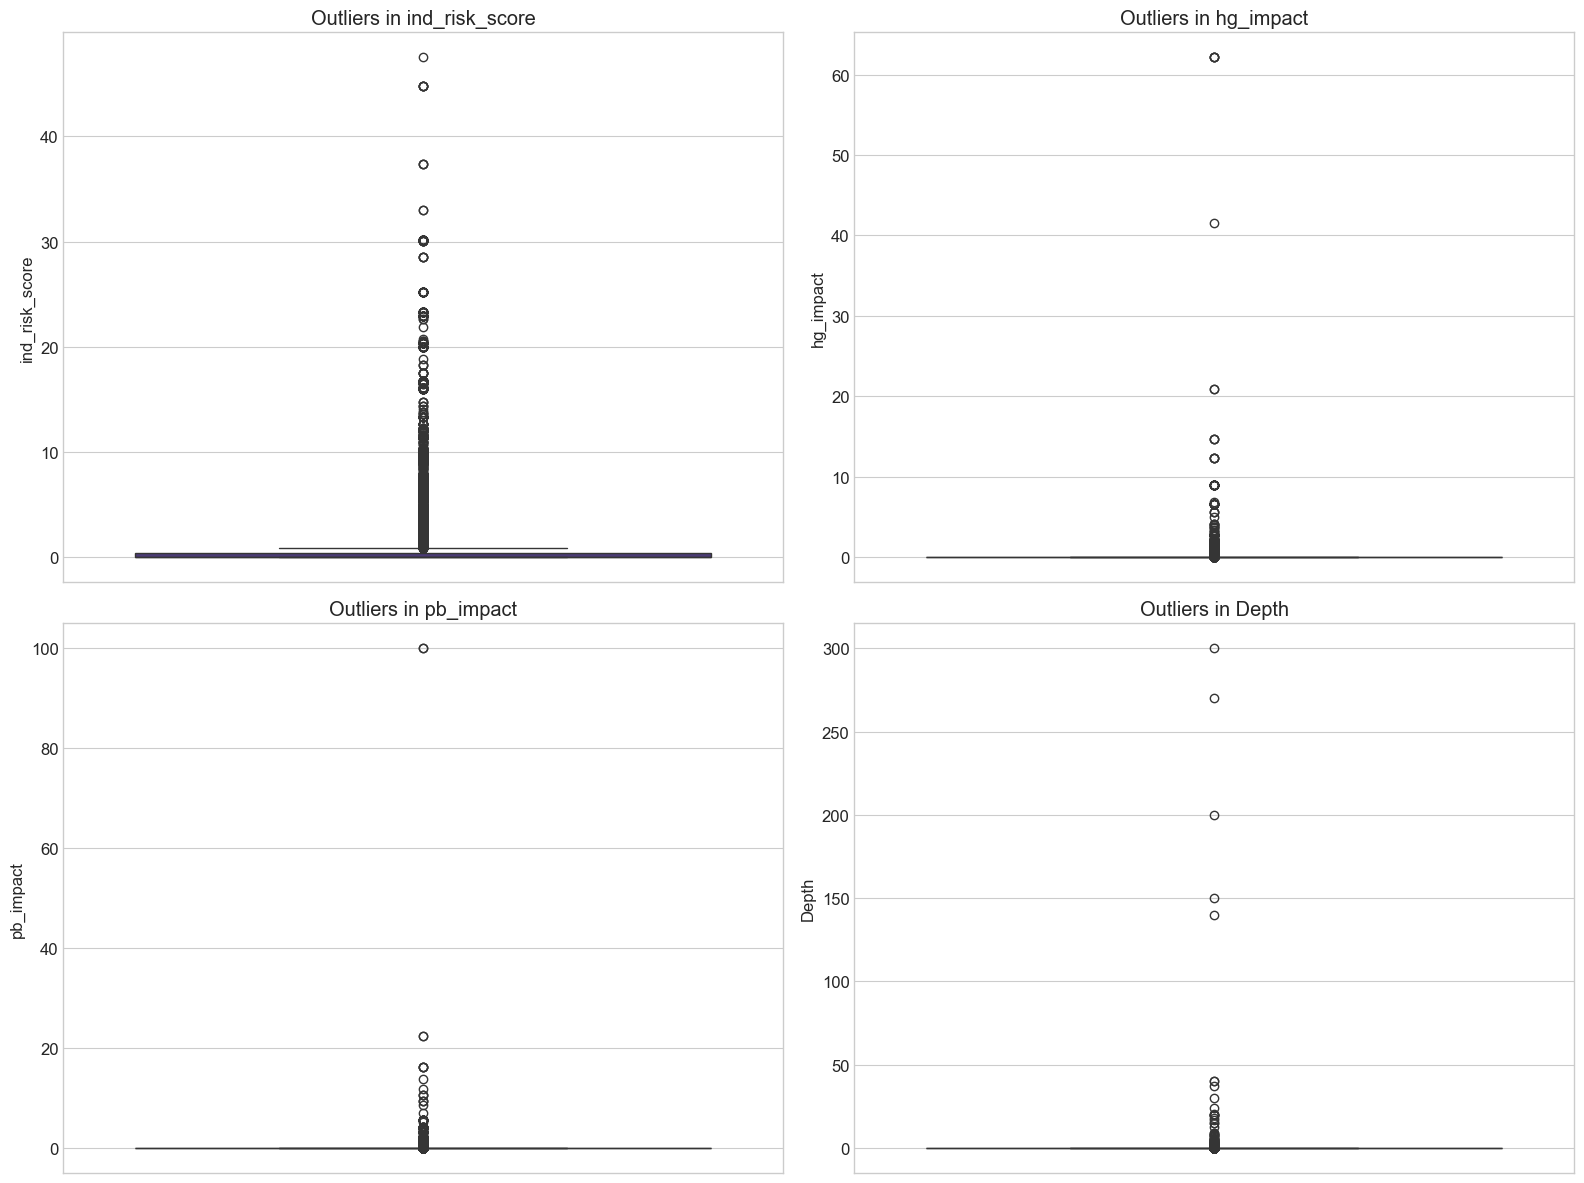


Relationship between outliers and target variable:

Target distribution for ind_risk_score:
  - Outliers (2553 samples):
    * Fair: 71.17%
    * Unknown: 25.19%
    * Good: 3.56%
    * Pending review: 0.08%
  - Non-outliers (11445 samples):
    * Fair: 72.66%
    * Unknown: 25.75%
    * Good: 1.40%
    * Pending review: 0.19%

Target distribution for hg_impact:
  - Outliers (2050 samples):
    * Fair: 72.93%
    * Unknown: 24.39%
    * Good: 2.59%
    * Pending review: 0.10%
  - Non-outliers (11948 samples):
    * Fair: 72.30%
    * Unknown: 25.86%
    * Good: 1.66%
    * Pending review: 0.18%

Target distribution for pb_impact:
  - Outliers (1694 samples):
    * Fair: 69.72%
    * Unknown: 27.86%
    * Good: 2.24%
    * Pending review: 0.18%
  - Non-outliers (12304 samples):
    * Fair: 72.76%
    * Unknown: 25.34%
    * Good: 1.73%
    * Pending review: 0.17%

Target distribution for Depth:
  - Outliers (1658 samples):
    * Fair: 86.49%
    * Unknown: 13.27%
    * Pending review: 

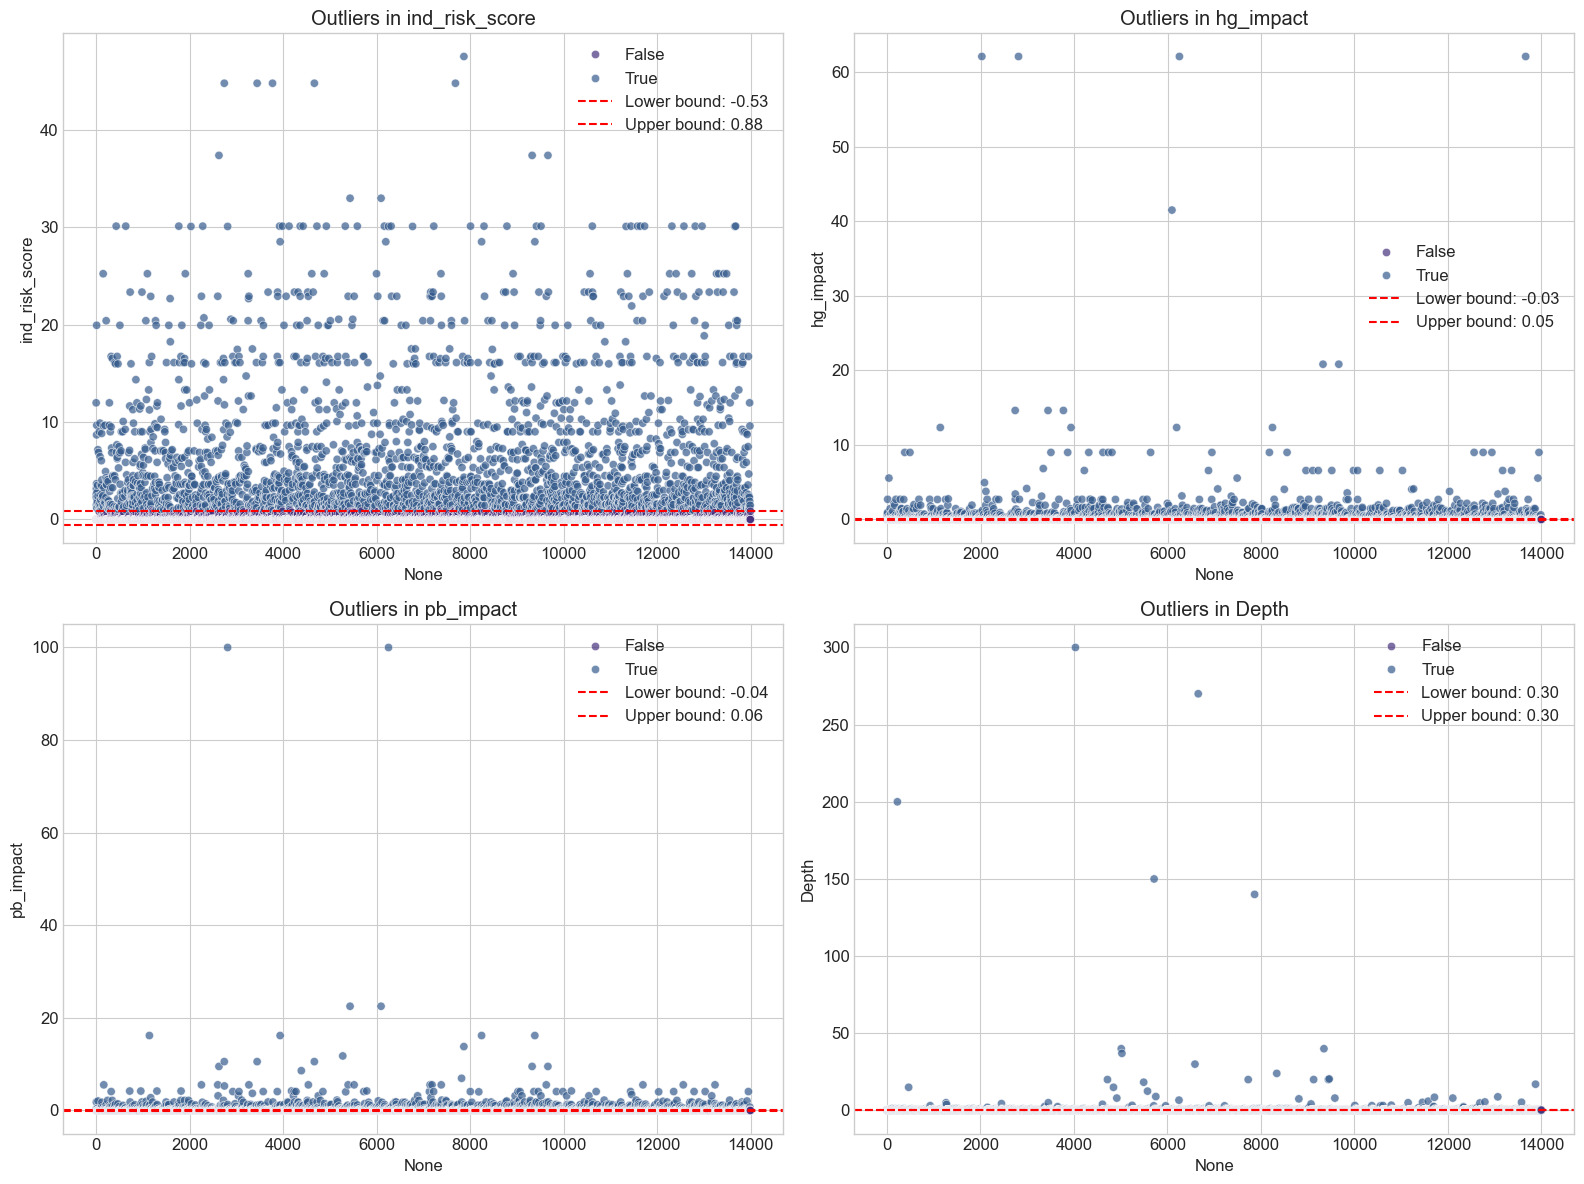

In [ ]:
# Outlier detection and analysis
print("\n" + "="*50)
print("OUTLIER ANALYSIS")
print("="*50)

# Function to detect outliers using IQR method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound, len(outliers)

# Analyze outliers in numerical features
print("\nOutlier analysis for numerical features:")
outlier_summary = {}

for col in numerical_features:
    if train[col].nunique() > 10:  # Skip categorical numerics or binary features
        outliers, lower, upper, count = detect_outliers(train, col)
        outlier_percent = (count / len(train)) * 100
        outlier_summary[col] = {
            'count': count,
            'percent': outlier_percent,
            'lower_bound': lower,
            'upper_bound': upper,
            'min': train[col].min(),
            'max': train[col].max()
        }

# Sort and display features with the most outliers
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index')
outlier_df = outlier_df.sort_values(by='percent', ascending=False)

print("\nTop 10 features with most outliers:")
for col, row in outlier_df.head(10).iterrows():
    print(f"{col}:")
    print(f"  - Outliers: {row['count']} ({row['percent']:.2f}%)")
    print(f"  - Bounds: [{row['lower_bound']:.4f}, {row['upper_bound']:.4f}]")
    print(f"  - Actual range: [{row['min']:.4f}, {row['max']:.4f}]")

# Visualize outliers for top features with most outliers
plt.figure(figsize=(16, 12))
for i, col in enumerate(outlier_df.head(4).index):
    plt.subplot(2, 2, i+1)
    
    # Box plot to visualize outliers
    sns.boxplot(y=train[col])
    plt.title(f'Outliers in {col}')
    plt.tight_layout()
plt.savefig('../reports/figures/outliers_boxplot.png', bbox_inches='tight')
plt.show()

# Analyze effect of outliers on target
print("\nRelationship between outliers and target variable:")
for col in outlier_df.head(5).index:
    outliers, lower, upper, _ = detect_outliers(train, col)
    outlier_indices = outliers.index
    
    # Check distribution of target for outliers vs. non-outliers
    outlier_target_dist = train.loc[outlier_indices, 'Data Quality'].value_counts(normalize=True) * 100
    non_outlier_target_dist = train.loc[~train.index.isin(outlier_indices), 'Data Quality'].value_counts(normalize=True) * 100
    
    print(f"\nTarget distribution for {col}:")
    print(f"  - Outliers ({len(outlier_indices)} samples):")
    for quality, percent in outlier_target_dist.items():
        print(f"    * {quality}: {percent:.2f}%")
    
    print(f"  - Non-outliers ({len(train) - len(outlier_indices)} samples):")
    for quality, percent in non_outlier_target_dist.items():
        print(f"    * {quality}: {percent:.2f}%")

# Add a scatter plot to visualize outliers
plt.figure(figsize=(16, 12))
for i, col in enumerate(outlier_df.head(4).index):
    plt.subplot(2, 2, i+1)
    
    # Get outlier information
    outliers, lower, upper, _ = detect_outliers(train, col)
    outlier_indices = outliers.index
    
    # Create a new column to identify outliers
    train_temp = train.copy()
    train_temp['is_outlier'] = train_temp.index.isin(outlier_indices)
    
    # Plot
    sns.scatterplot(x=train_temp.index, y=col, hue='is_outlier', data=train_temp, alpha=0.7)
    plt.axhline(y=lower, color='r', linestyle='--', label=f'Lower bound: {lower:.2f}')
    plt.axhline(y=upper, color='r', linestyle='--', label=f'Upper bound: {upper:.2f}')
    plt.title(f'Outliers in {col}')
    plt.legend()
    plt.tight_layout()
plt.savefig('../reports/figures/outliers_scatter.png', bbox_inches='tight')
plt.show()

In [ ]:
# Summary of insights
print("\n" + "="*50)
print("SUMMARY OF EDA INSIGHTS")
print("="*50)

# 1. Target Variable Distribution
print("\n1. Target Variable Distribution:")
for quality, count in target_counts.items():
    percentage = (count / len(train)) * 100
    print(f"   - {quality}: {count} samples ({percentage:.2f}%)")

# 2. Missing Values - more detailed information
print("\n2. Missing Values:")
print(f"   - Train dataset: {train.isnull().sum().sum()} missing values")
train_missing_cols = train_missing[train_missing > 0]
print(f"   - Number of columns with missing values in train: {len(train_missing_cols)}")
print("   - Top 5 columns with most missing values in train:")
for col, missing in zip(train_missing_cols.index[:5], train_missing_cols.values[:5]):
    print(f"     * {col}: {missing} missing ({missing/len(train)*100:.2f}%)")

print(f"   - Test dataset: {test.isnull().sum().sum()} missing values")
test_missing_cols = test_missing[test_missing > 0]
print(f"   - Number of columns with missing values in test: {len(test_missing_cols)}")
print("   - Top 5 columns with most missing values in test:")
for col, missing in zip(test_missing_cols.index[:5], test_missing_cols.values[:5]):
    print(f"     * {col}: {missing} missing ({missing/len(test)*100:.2f}%)")

# 3. Highly Skewed Numerical Features
print("\n3. Highly Skewed Numerical Features:")
high_skew = skewness[abs(skewness) > 1].sort_values(ascending=False)
if len(high_skew) > 0:
    for col, skew_val in zip(high_skew.index[:5], high_skew.values[:5]):
        print(f"   - {col}: skewness = {skew_val:.4f}")
        print(f"     * Range: [{train[col].min():.4f}, {train[col].max():.4f}]")
        print(f"     * Mean: {train[col].mean():.4f}, Median: {train[col].median():.4f}")
else:
    print("   No highly skewed numerical features found (|skewness| > 1)")

# 4. High Cardinality Categorical Features
print("\n4. High Cardinality Categorical Features:")
high_card = cat_unique_counts[cat_unique_counts > 10].sort_values(ascending=False)
if len(high_card) > 0:
    for col, count in zip(high_card.index[:5], high_card.values[:5]):
        print(f"   - {col}: {count} unique values")
        if train[col].nunique() <= 20:  # If not too many to display
            top_values = train[col].value_counts().head(3)
            print(f"     * Top 3 values: {', '.join([f'{v} ({c})' for v, c in zip(top_values.index, top_values.values)])}")
else:
    print("   No high cardinality categorical features found (> 10 unique values)")

# 5. Top Correlated Feature Pairs - improved format
print("\n5. Top Correlated Feature Pairs:")
# Create a more readable format for correlation pairs
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.5:  # Only show strong correlations
            corr_pairs.append((correlation_matrix.columns[i], 
                              correlation_matrix.columns[j], 
                              correlation_matrix.iloc[i, j]))

# Sort by absolute correlation value
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

# Display top pairs with formatted output
if corr_pairs:
    for pair in corr_pairs[:5]:
        print(f"   - {pair[0]} & {pair[1]}: {pair[2]:.4f}")
else:
    print("   No strongly correlated feature pairs found (|correlation| > 0.5)")

# 6. Add information about potential important features for prediction
print("\n6. Potential Important Features for Prediction:")
# This section can be expanded based on your EDA findings
print("   Based on the exploratory analysis, these feature groups might be important:")
print("   - Environmental factors: temperature, rainfall, humidity")
print("   - Land use percentages (urban_pct, forest_pct, etc.)")
print("   - Parameter codes and categories")
print("   - Impact and risk scores")
print("   - Sampling and analysis methods")

# 7. Add potential data preparation steps
print("\n7. Recommended Data Preparation Steps:")
print("   - Handle missing values (consider imputation strategies)")
print("   - Encode categorical variables (one-hot, target, or label encoding)")
print("   - Transform skewed numerical features (log transformation)")
print("   - Handle spatial and temporal features")
print("   - Deal with high cardinality features (grouping or embedding)")

print("\n8. Duplicate Data Analysis:")
print(f"   - Train dataset: {train_duplicates} exact duplicates, {train_feature_duplicates} feature-based duplicates")
print(f"   - Test dataset: {test_duplicates} exact duplicates, {test_feature_duplicates} feature-based duplicates")

print("\n9. Outlier Analysis:")
print(f"   - Total features analyzed: {len(outlier_summary)}")
print("   - Top 5 features with most outliers:")
for col, row in outlier_df.head(5).iterrows():
    print(f"     * {col}: {row['count']} outliers ({row['percent']:.2f}%)")

print("\nEDA Complete. Check the generated visualizations in the reports/figures directory.")


SUMMARY OF EDA INSIGHTS

1. Target Variable Distribution:
   - Fair: 10133 samples (72.39%)
   - Unknown: 3590 samples (25.65%)
   - Good: 251 samples (1.79%)
   - Pending review: 24 samples (0.17%)

2. Missing Values:
   - Train dataset: 169114 missing values
   - Number of columns with missing values in train: 41
   - Top 5 columns with most missing values in train:
     * Value Flags: 11828 missing (84.50%)
     * Analysis Method Code: 11597 missing (82.85%)
     * Longitude: 7073 missing (50.53%)
     * pressure_hPa: 6814 missing (48.68%)
     * analytical_program: 6789 missing (48.50%)
   - Test dataset: 70934 missing values
   - Number of columns with missing values in test: 41
   - Top 5 columns with most missing values in test:
     * Value Flags: 5019 missing (83.65%)
     * Analysis Method Code: 4959 missing (82.65%)
     * Longitude: 3010 missing (50.17%)
     * pressure_hPa: 2914 missing (48.57%)
     * water_body_type: 2905 missing (48.42%)

3. Highly Skewed Numerical Fea